# Reservoir Computing: ESN con lRNN {-}

## Applicazione su Oscillatore Armonico {-}
### Ilenia Amato {-}

***

Oscillatore armonico (forma ODE e matriciale):
$$\frac{d^2x}{dt^2} + \omega^2 x = 0$$


$$
\frac{d}{dt}\begin{pmatrix}x\\v_x\end{pmatrix} =
\begin{pmatrix}0&1\\-ω^2&0\end{pmatrix}\begin{pmatrix}x\\v_x\end{pmatrix}
$$
$$\dot{\mathbf{r}} = \begin{pmatrix} 0 & 1 \\ -\omega^2 & 0 \end{pmatrix} \mathbf{r}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

# Generazione dei dati (OA)

Produco il dataset di allenamento. Questo sarà una matrice $\mathbf{X}\in\mathbb{R}^{T\times D}$, in cui $T$ sono i tempi (le osservazioni), e $D$ è la dimensionalità del problema.

Divido il dataset in una parte di training, una di spin-up e una di test.

(2000, 2)


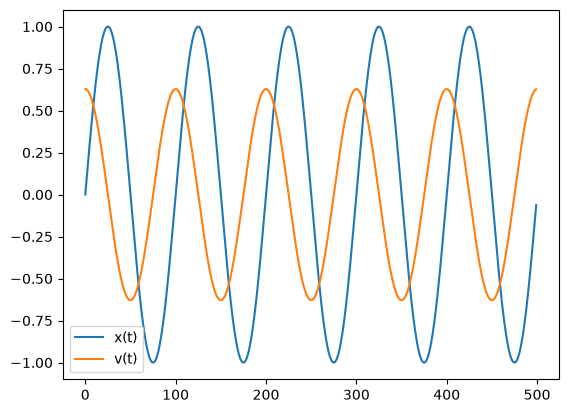

In [5]:
# =============================================================================
# 1. GENERAZIONE DATI: L'OSCILLATORE ARMONICO
# =============================================================================
# Parametri dell'oscillatore
omega = 2.0 * np.pi * 0.1 # Frequenza di oscillazione
dt = 0.1                   # Passo temporale di campionamento
t = np.arange(0.0, 1000.0, dt)

# Lo stato del sistema ha 2 componenti: [posizione, velocità]
x = np.column_stack((np.sin(omega * t), omega * np.cos(omega * t)))

# Splitting dei dati. 
# Il transitorio (spin-up) è essenziale per allineare 
# lo stato interno ai dati prima di iniziare la predizione.
n_spin, n_train, n_test = 1000, 6000, 2000
i_spin, i_train, i_test = n_spin, n_train + n_spin, n_train + n_spin + n_test

# x_train funge da 'y_target' per l'addestramento
x_spin = x[:i_spin]
x_train  = x[i_spin:i_train]
x_test  = x[i_train:i_test]

print(x_test.shape)
plt.plot(x_test[:500,:], label=["x(t)", "v(t)"])
plt.legend()
plt.show()

(10000, 2)
Errore massimo odeint vs soluzione analitica: 1.352e-05


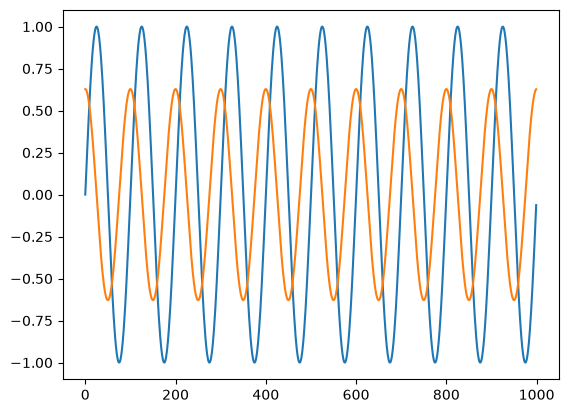

In [3]:
### VERIFICA NUMERICA DELLA SOLUZIONE ANALITICA
### (CODICE GENERALIZZABILE PER SISTEMA DINAMICO)
from scipy.integrate import odeint

# Definiamo il sistema dinamico
def oscillatore(stato, t, omega):
    x, v = stato
    dxdt = v
    dvdt = -(omega**2) * x
    return [dxdt, dvdt]

# Condizione iniziale: posizione=0, velocità=omega
stato_iniziale = [0.0, omega] 
# Integrazione numerica
x_integrato = odeint(oscillatore, stato_iniziale, t, args=(omega,))

print(x_integrato.shape)
plt.plot(x_integrato[:1000,], label=["x(t)", "v(t)"])

max_error = np.max(np.abs(x_integrato - x))
print(f"Errore massimo odeint vs soluzione analitica: {max_error:.3e}")

# Setup della lRNN e funzioni della dinamica

Inizializzo gli iperparametri necessari per l'architettura del RC.

Creo le matrici necessarie: `W` è la matrice sinaptica, `Win` è la matrice di input e `b` è il vettore di bias.

In [6]:
# =============================================================================
# 2. INIZIALIZZAZIONE DEL RESERVOIR (lRNN)
# =============================================================================
SEED = 42
np.random.seed(SEED) #Seed fissato per riproducibilità
N = 300    # Numero di neuroni
D = 2      # Dimensione dell'input/output
rho = 0.9 # Raggio spettrale (deve essere < 1 per la Echo State Property)
alpha = 0.9 # Leak rate (parametro di inerzia: 1 = niente inerzia, dinamica veloce)
input_scaling = 1.0 ###1.5

# Matrice ricorrente W
W_raw = np.random.randn(N, N)
# Calcolo degli autovalori per trovare il raggio spettrale effettivo
eigenvalues = np.linalg.eigvals(W_raw)
max_eigenvalue = np.max(np.abs(eigenvalues))
# Scalatura esatta: ora W ha raggio spettrale pari a 'rho'
W = (W_raw / max_eigenvalue) * rho

# Matrice di input (Win) e bias (b)
Win = input_scaling*np.random.randn(N, D)/np.sqrt(N)
b = np.random.randn(N)/np.sqrt(N)

print(W.shape, Win.shape, b.shape)

(300, 300) (300, 2) (300,)


Implemento il singolo step e la dinamica guidata (open_loop) e autonoma (closed_loop).

Reservoir Computing con lRNN (ODE ed Euler discretization):
\begin{equation*}
\tau\frac{d\mathbf{h}(t)}{dt} = -\mathbf{h}(t) + \left( \mathbf{W} \mathbf{h}(t) + \mathbf{W}_{\text{in}} \mathbf{u}(t) + \mathbf{b} \right)
\end{equation*}

---

$$ \frac{\mathbf{h}_{t+1}-\mathbf{h}_t}{dt} = \frac{1}{\tau} (-\mathbf{h}_t + \mathbf{W}\mathbf{h}_t + \mathbf{W}_{\text{in}}\,\mathbf{u}_t + \mathbf{b})$$

$$ \mathbf{h}_{t+1} = \mathbf{h}_t + \frac{dt}{\tau} (-\mathbf{h}_t + \mathbf{W}\mathbf{h}_t + \mathbf{W}_{\text{in}}\,\mathbf{u}_t + \mathbf{b})$$

Definendo $\alpha=\frac{dt}{\tau}$ si ha infine:
$$\boxed{\mathbf{h}_{t+1} = (1 - \alpha)\,\mathbf{h}_t + \alpha\left( \mathbf{W} \mathbf{h}_t + \mathbf{W}_{\text{in}}\,\mathbf{u}_t + \mathbf{b} \right)}$$

In [7]:
# =============================================================================
# 3. LE FUNZIONI DELLA DINAMICA
# =============================================================================
def step_linear(h_t, u_t, W, Win, b, alpha):
    """
    Equazione di aggiornamento di stato discreto per una lRNN.
    """
    return (1 - alpha) * h_t + alpha * (W @ h_t + Win @ u_t + b)

def open_loop(u_seq, h_init, W, Win, b, alpha):
    """
    Fase di "ascolto": la rete è guidata (driven) dal segnale esterno u_seq.
    """
    h_states = []
    h = h_init
    for u in u_seq:
        h = step_linear(h, u, W, Win, b, alpha)
        h_states.append(h)
    return np.array(h_states)

def closed_loop(steps, h_init, Wout, W, Win, b, alpha):
    """
    Fase "predittiva": la rete si guida da sola. L'uscita diventa il nuovo input.
    """
    y_preds = []
    h = h_init
    for _ in range(steps):
        # Calcolo dell'uscita lineare
        y = Wout @ h
        y_preds.append(y)
        # Aggiornamento dello stato usando l'uscita appena predetta come input
        h = step_linear(h, y, W, Win, b, alpha)
    return np.array(y_preds)

# Addestramento, predizione temporale e confronto visivo

Faccio evolvere la rete con il set di spin-up.

Creo la serie temporale $\mathbf{H}\in\mathbb{R}^{T\times N}$ dello stato interno a partire dalla serie in input $\mathbf{X}$.

Alleno la matrice di output `Wout` tramite i minimi quadrati aggiungendo un parametro regolarizzante, ovvero applicando la regressione di Ridge:
$$\mathbf{W}_{\mathrm{out}} = \mathbf{Y}^T\mathbf{H}\left(\mathbf{H}^T\mathbf{H}+\lambda\mathbf{I}\right)^{-1}$$

Faccio poi evolvere liberamente (in modo autonomo).

In [9]:
# =============================================================================
# 4. ADDESTRAMENTO (RIDGE REGRESSION) E PREDIZIONE TEMPORALE TIME-SHIFT
# =============================================================================
from sklearn.linear_model import ridge_regression

# 4.1 Fase di "riscaldamento" (spin-up) per sincronizzare il serbatoio 
# con lo stato finale prima del training
h_spin_states = open_loop(x_spin, np.zeros(N), W, Win, b, alpha)

# 4.2 Ascolto dei dati di training
h_train = open_loop(x_train, h_spin_states[-1], W, Win, b, alpha)

# Chiedo allo stato h[t] di prevedere il segnale x[t+1]
H_train_shifted = h_train[:-1]  # Prendo gli stati da 0 a T-1
Y_target_shifted = x_train[1:]  # Prendo i target da 1 a T

# 4.3 Calcolo di Wout tramite pseudo-inversa regolarizzata (Tikhonov)
Wout = ridge_regression(H_train_shifted, Y_target_shifted, 1e-8)
#lam = 1e-8  # Regolarizzazione
#H_cov = H_train_shifted.T @ H_train_shifted # Matrice di covarianza degli stati
#Wout = Y_target_shifted.T @ H_train_shifted @ np.linalg.inv(H_cov + lam * np.eye(N))

# 4.4 Quantifico errore di training
train_pred = H_train_shifted @ Wout.T
train_rmse = np.sqrt(np.mean((train_pred - Y_target_shifted)**2))
print(f"Training RMSE one-step-ahead = {train_rmse:.6e}")

# 4.5 Predizione autonoma
y_pred = closed_loop(n_test, h_train[-1], Wout, W, Win, b, alpha)

Training RMSE one-step-ahead = 7.266006e-13


(6000, 300) (5999, 300)


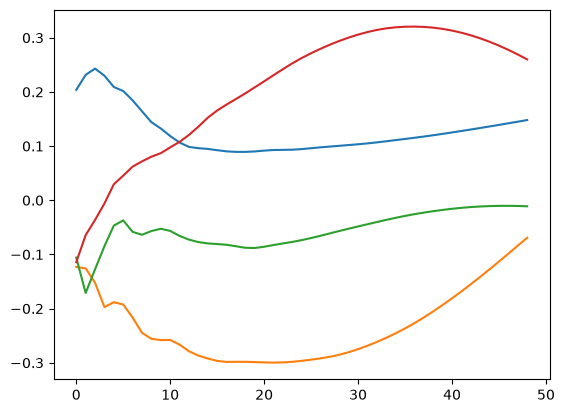

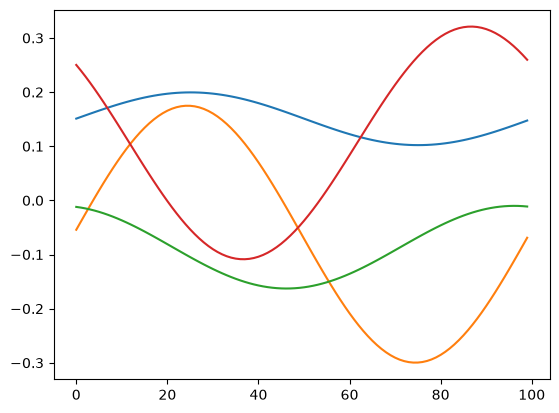

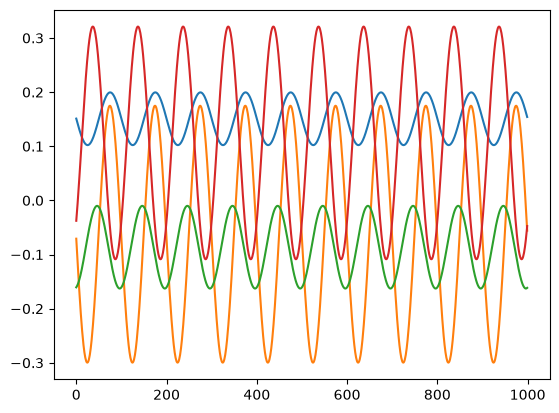

In [10]:
# Do un'occhiata allo stato interno

print(h_train.shape, H_train_shifted.shape)
plt.plot(h_spin_states[1:50, 1:5])
plt.show()
plt.plot(h_spin_states[50:150, 1:5])
plt.show()
plt.plot(h_train[:1000, 1:5])
plt.show()

Terminato l'addestramento, il sistema viene disconnesso dall'input esterno e lasciato evolvere liberamente (*closed-loop* o predizione autonoma). 

Se il training è sufficientemente efficace, la dinamica autonoma del reservoir può riprodurre le principali caratteristiche dinamiche del sistema target, nello specifico producendo traiettorie stabili nello spazio delle fasi, senza divergere all'infinito (esplosione) né decadere a zero (smorzamento).

Comparo quindi l'output predetto con i dati di test.

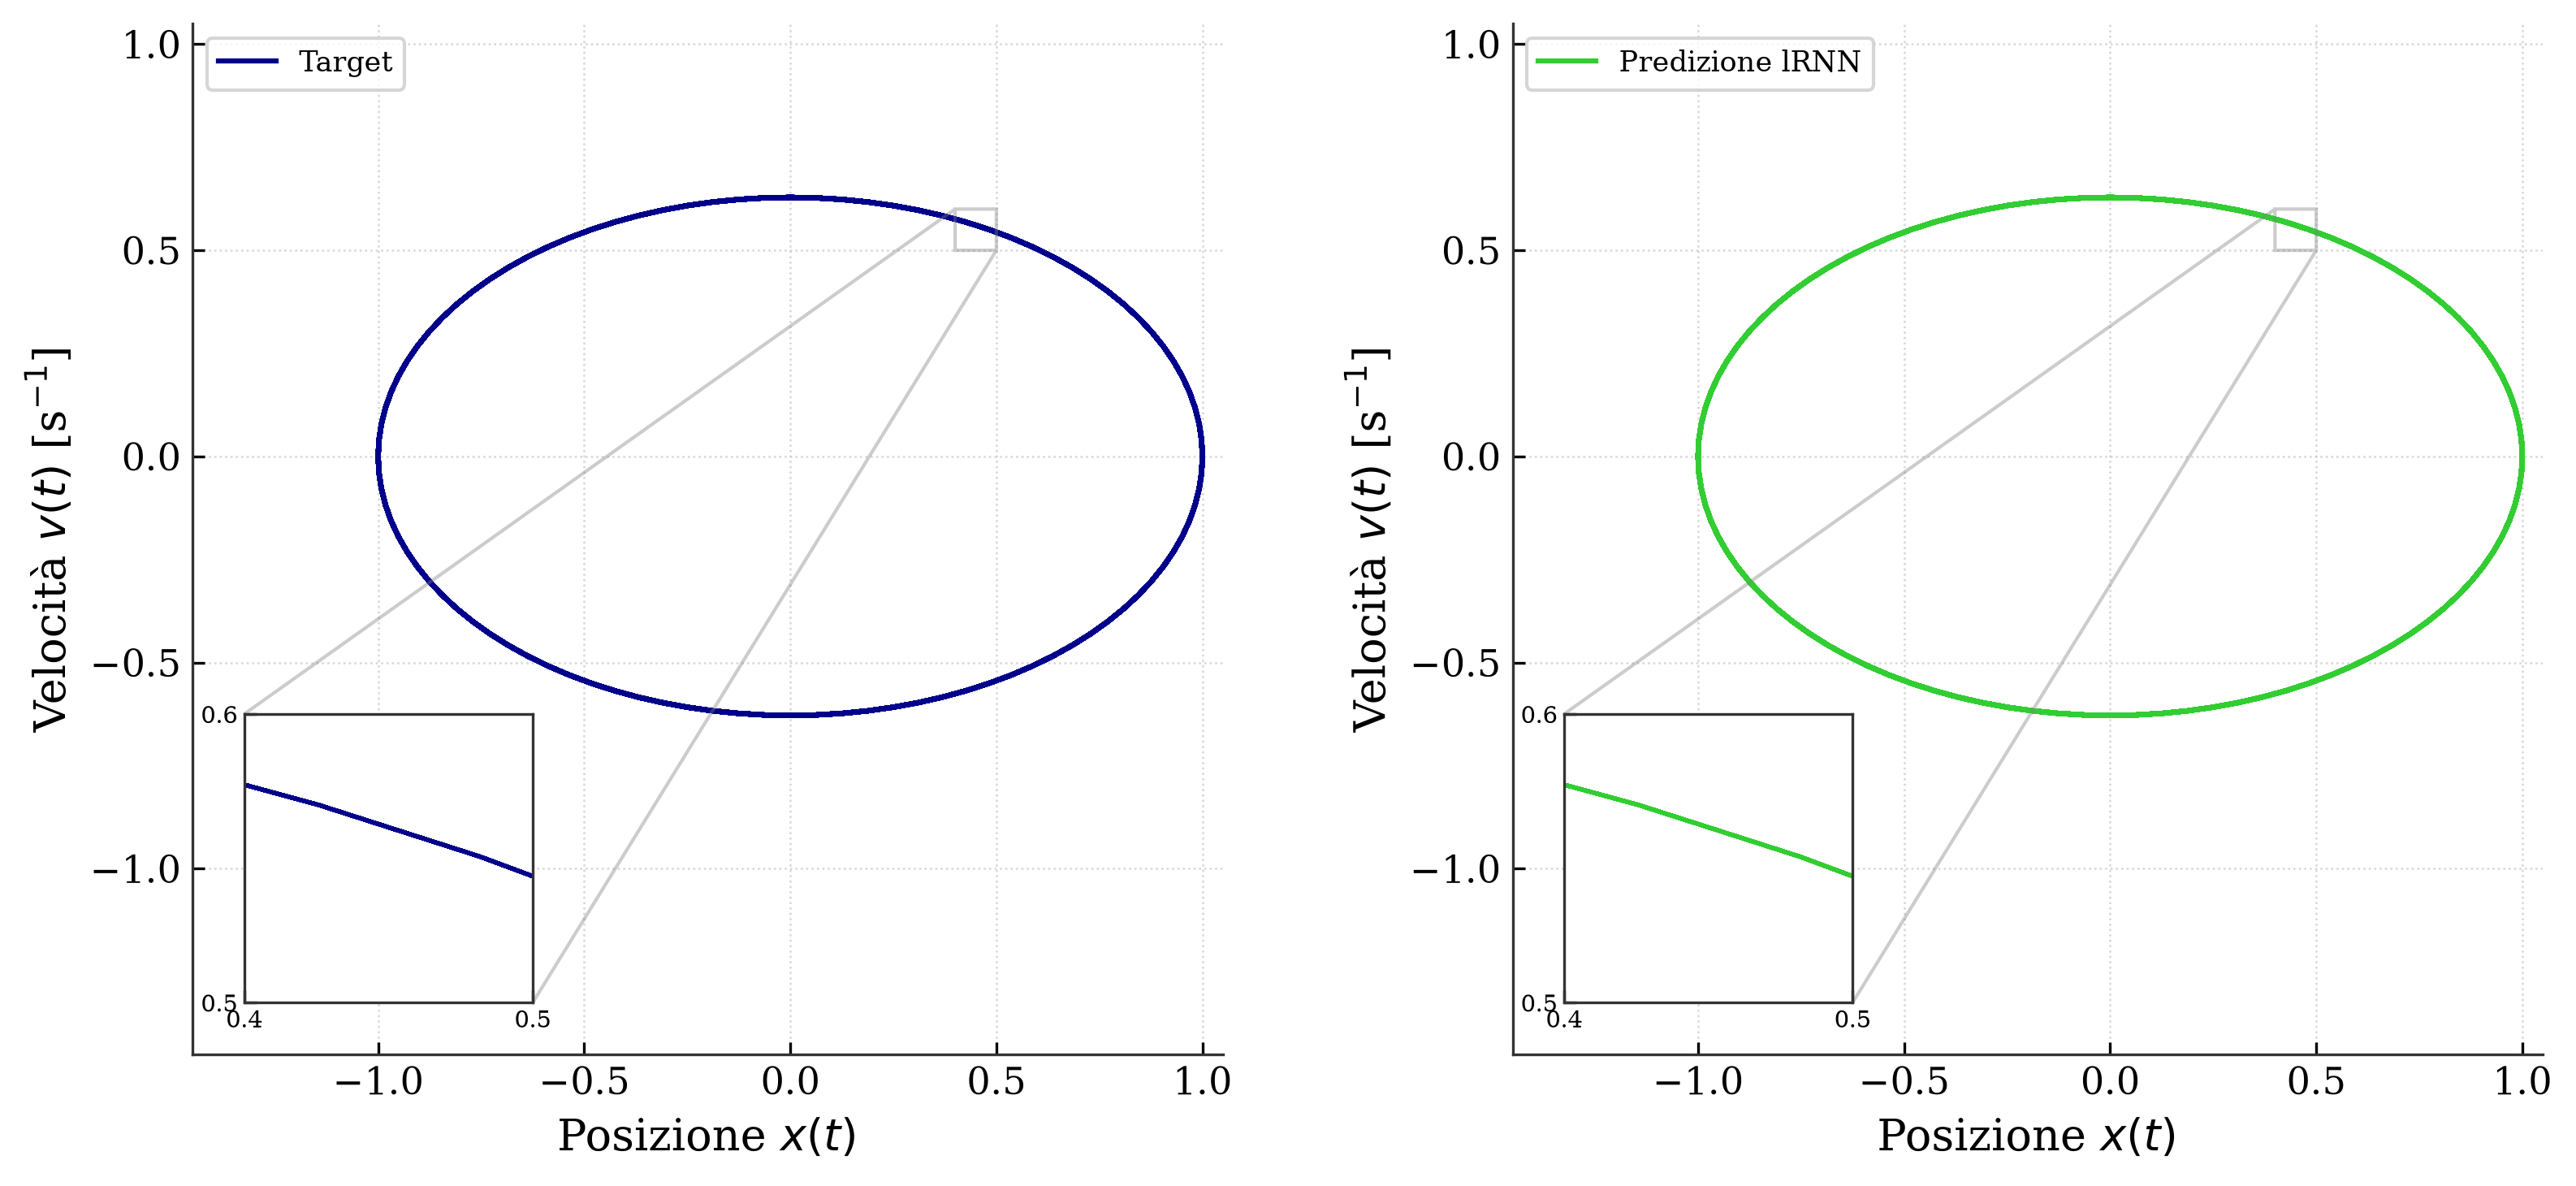

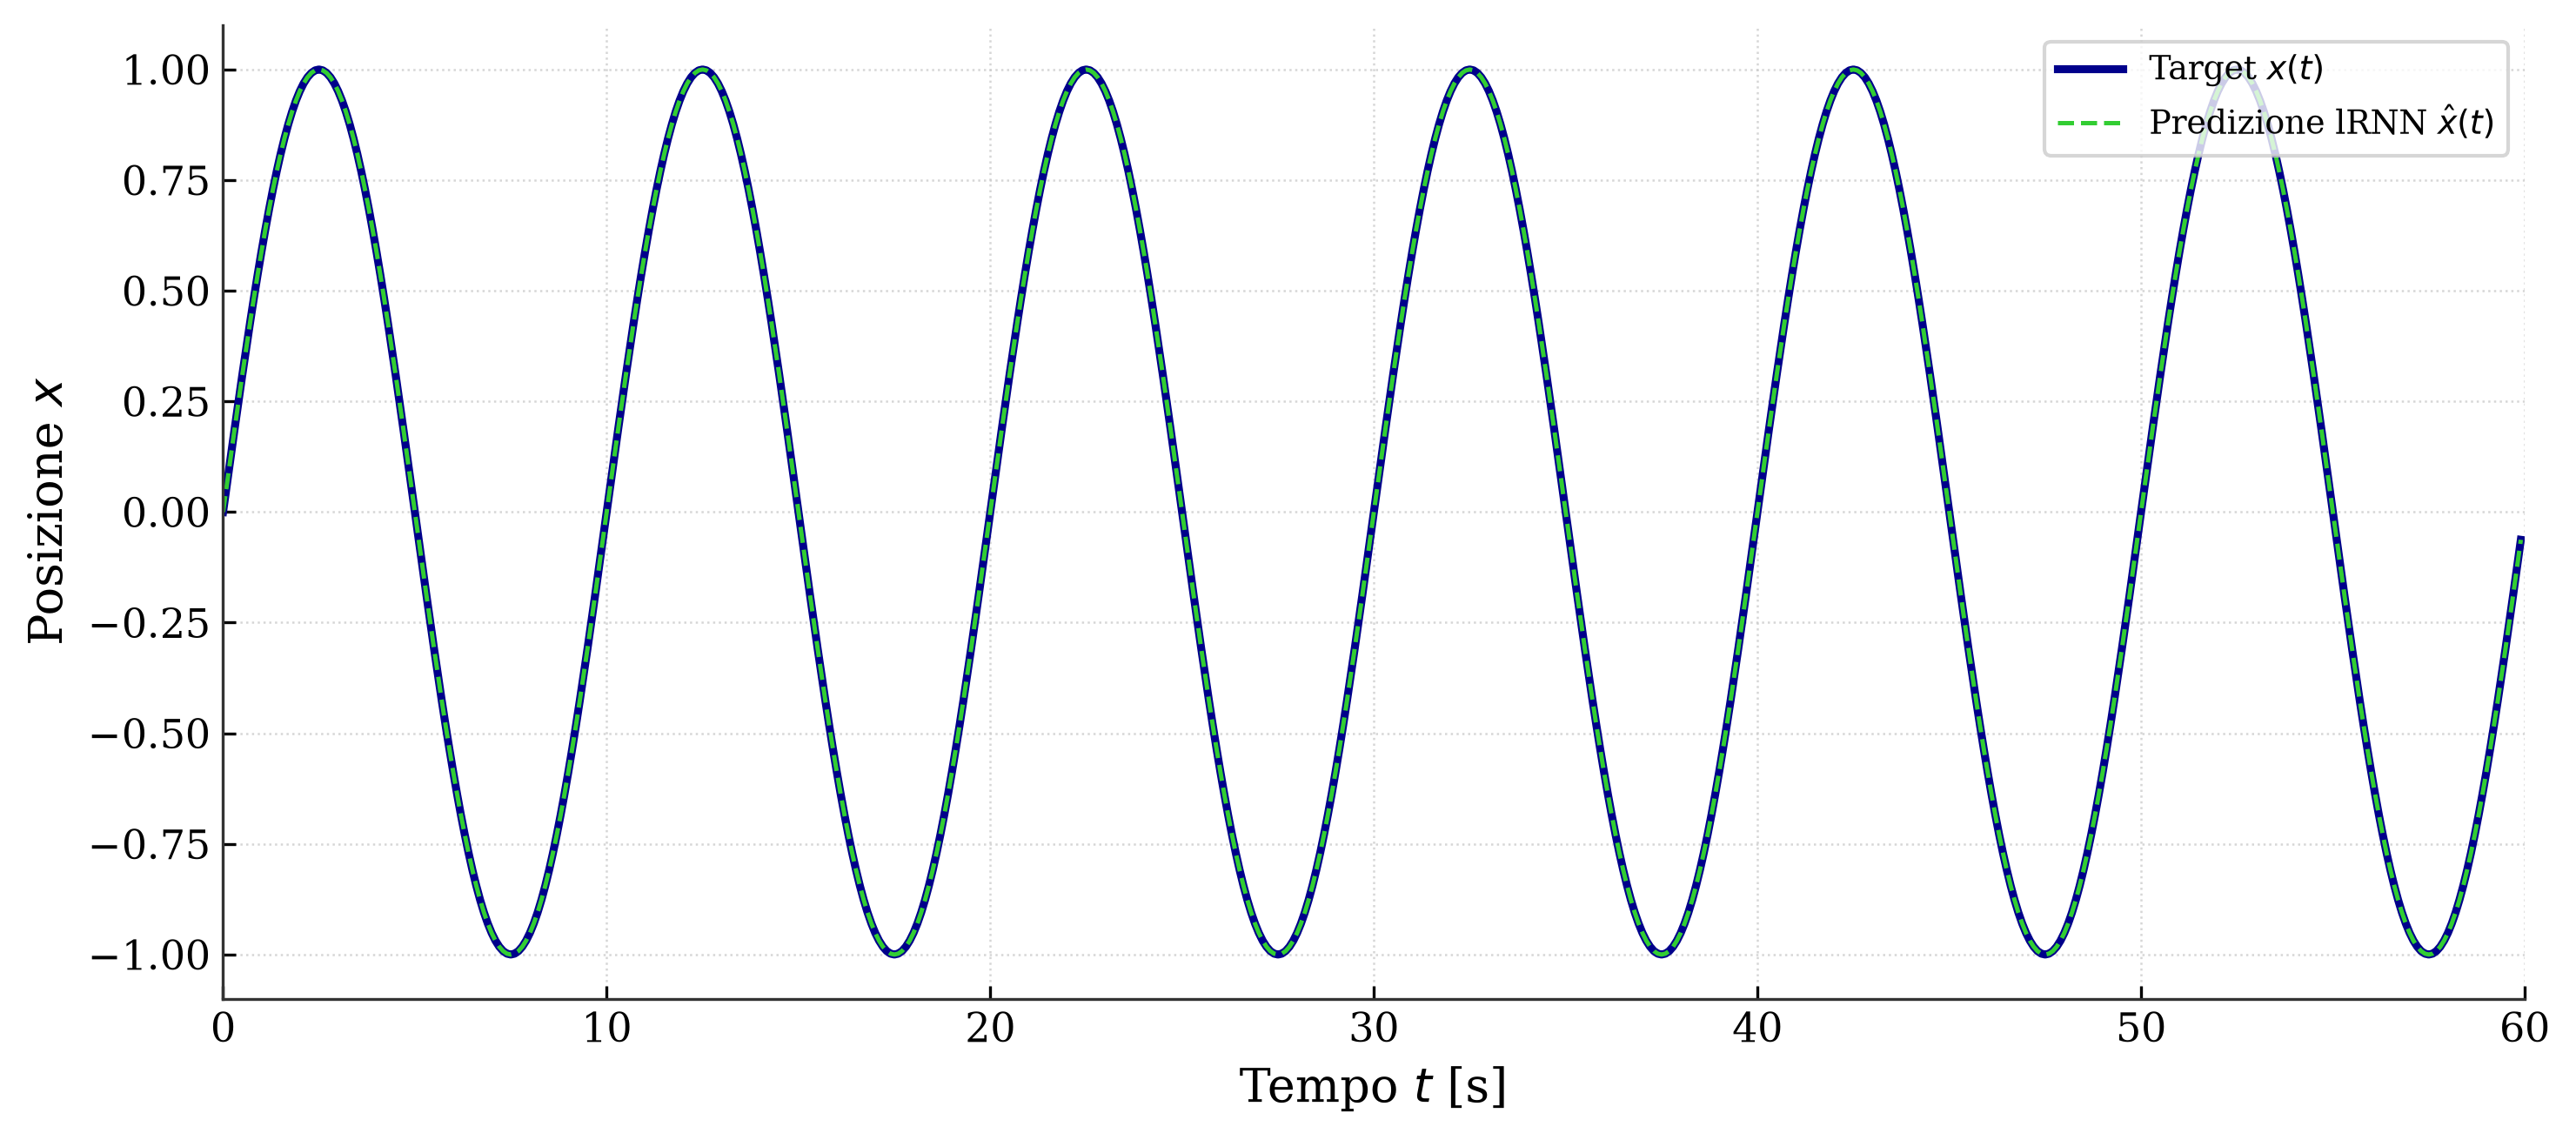

In [11]:
# =============================================================================
# 5. VISUALIZZAZIONE RISULTATI
# =============================================================================
#Configurazione parametri globali
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 13         
plt.rcParams['xtick.labelsize'] = 11        
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['xtick.direction'] = 'in'   
plt.rcParams['ytick.direction'] = 'in'


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), dpi=300)

ax1.plot(x_test[:, 0], x_test[:, 1], 'darkblue', linewidth=1.5, label='Target')
#ax1.set_title("Spazio delle fasi (x, v)\nsistema target", fontsize=13)
ax1.set_xlabel("Posizione $x(t)$")
ax1.set_ylabel("Velocità $v(t)$ [s$^{-1}$]")
ax1.set_xlim(-1.45, 1.05)
ax1.set_ylim(-1.45, 1.05)
ax1.grid(True, linestyle=':', alpha=0.8, color='#cccccc', linewidth=0.6)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_aspect('equal', 'box') ###

# --- INSET ZOOM TARGET ---
ax1_inset = ax1.inset_axes([0.05, 0.05, 0.28, 0.28])
ax1_inset.plot(x_test[:, 0], x_test[:, 1], 'darkblue', linewidth=1.2)
ax1_inset.set_xlim(0.4, 0.5)
ax1_inset.set_ylim(0.5, 0.6)
ax1_inset.grid(True, linestyle='--', alpha=0.8, linewidth=0.5)
ax1_inset.set_xticks([0.4, 0.5])
ax1_inset.set_yticks([0.5, 0.6])
ax1_inset.tick_params(axis='both', which='major', labelsize=7, pad=2)
ax1.indicate_inset_zoom(ax1_inset, edgecolor="gray", alpha=0.4)


ax2.plot(y_pred[:, 0], y_pred[:, 1], 'limegreen',linewidth=1.5, label='Predizione lRNN')
#ax2.set_title("Spazio delle fasi (x, v)\npredizione autonoma Reservoir (lRNN)", fontsize=13)
ax2.set_xlabel("Posizione $x(t)$")
ax2.set_ylabel("Velocità $v(t)$ [s$^{-1}$]")
ax2.set_xlim(-1.45, 1.05)
ax2.set_ylim(-1.45, 1.05)
ax2.grid(True, linestyle=':', alpha=0.8, color='#cccccc', linewidth=0.6)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_aspect('equal', 'box') ###

# --- INSET ZOOM RESERVOIR ---
ax2_inset = ax2.inset_axes([0.05, 0.05, 0.28, 0.28])
ax2_inset.plot(y_pred[:, 0], y_pred[:, 1], 'limegreen', linewidth=1.2)
ax2_inset.set_xlim(0.4, 0.5)
ax2_inset.set_ylim(0.5, 0.6)
ax2_inset.grid(True, linestyle='--', alpha=0.8, linewidth=0.5)
ax2_inset.set_xticks([0.4, 0.5])
ax2_inset.set_yticks([0.5, 0.6])
ax2_inset.tick_params(axis='both', which='major', labelsize=7, pad=2)
ax2.indicate_inset_zoom(ax2_inset, edgecolor="gray", alpha=0.4)

ax1.legend(loc='upper left', fontsize=8.5, frameon=True, facecolor='white')
ax2.legend(loc='upper left', fontsize=8.5, frameon=True, facecolor='white')
plt.tight_layout()
#plt.savefig('spaziofasiOA.pdf', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 4.5), dpi=300)
time_test = np.arange(n_test) * dt #tempo fisico
plt.plot(time_test[:600], x_test[:600, 0], color='darkblue', linestyle='-', linewidth=2.2, label='Target $x(t)$')
plt.plot(time_test[:600], y_pred[:600, 0], color='limegreen', linestyle='--', linewidth=1.2, label=r'Predizione lRNN $\hat{x}(t)$')
#plt.title("Evoluzione temporale della posizione\nConfronto traiettoria target vs RC in closed-loop", fontsize=13)
plt.xlabel("Tempo $t$ [s]")
plt.ylabel("Posizione $x$")
plt.legend(loc='upper right',fontsize=9, frameon=True)
plt.grid(True, linestyle=':', alpha=0.8, color='#cccccc', linewidth=0.6)
ax = plt.gca()
ax.set_xlim(time_test[0], time_test[600])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

#tratteggio lungo (0, (15, 12))
#plt.savefig('traiettoriaOA.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Inferenza spettrale

Vediamo ora il confronto nel piano complesso tra gli autovalori del sistema originario e gli autovalori inferiti dal Reservoir Computing. 

L'obiettivo è verificare empiricamente se l'architettura sia in grado di estrarre le frequenze naturali del sistema dinamico analizzato a partire dai dati campionati.

## Il sistema fisico originario (tempo continuo)
In un sistema di equazioni differenziali lineari, la matrice dei coefficienti coincide esattamente con la **matrice Jacobiana** (ovvero la matrice delle derivate parziali del sistema rispetto alle sue variabili di stato).

Prendendo il sistema di equazioni per un oscillatore armonico abbiamo:
$$\begin{cases} \frac{\mathrm{d}x}{\mathrm{d}t} = v_x \\ \frac{\mathrm{d}v_x}{\mathrm{d}t} = -\omega^2 x \end{cases}$$
La matrice Jacobiana $A$ associata è:
$$\mathbf{A} = \begin{pmatrix} 0 & 1 \\ -\omega^2 & 0 \end{pmatrix}$$
I suoi autovalori $\lambda_A = \pm i\omega$ sono puramente immaginari e rappresentano le frequenze naturali di oscillazione del sistema fisico nel dominio del tempo continuo.

## La dinamica autonoma del Reservoir (tempo continuo)
Affinché la rete neurale replichi questa dinamica, deve implementare queste esatte frequenze. Quando il sistema viene addestrato e l'output $\mathbf{u} = \mathbf{W}_{\text{out}}\mathbf{h}$ viene reiniettato in ingresso, la rete diventa un sistema dinamico autonomo. Ignorando il termine costante di bias (che trasla il punto di equilibrio nello spazio delle fasi ma non altera lo spettro delle frequenze di oscillazione), l'evoluzione dello stato interno nel tempo continuo è governata da:
$$\tau\frac{\mathrm{d}\mathbf{h}(t)}{\mathrm{d}t} = (\mathbf{W}_{\mathrm{tot}} - \mathbf{I})\mathbf{h}(t)$$
Definendo la matrice dei pesi complessiva $\mathbf{W}_{\text{tot}} = \mathbf{W} + \mathbf{W}_{\mathrm{in}}\mathbf{W}_{\mathrm{out}}$, l'equazione assume la forma compatta:
$$\tau\frac{\mathrm{d}\mathbf{h}(t)}{\mathrm{d}t} = (\mathbf{W}_{\mathrm{tot}} - \mathbf{I})\mathbf{h}(t)$$
Otteniamo così la matrice efficace che governa il sistema nel dominio continuo:
$$\mathbf{W}_{\mathrm{eff}}^C = \frac {1}{\tau}(\mathbf{W}_{\mathrm{tot}}-\mathbf{I})$$
Dalla quale si ricava lo spettro degli autovalori:
$$\lambda_C = \frac {\lambda_{W_{\mathrm{tot}}}-1}{\tau}$$
Questa equazione descrive la dinamica dalla prospettiva puramente fisica: rappresenta l'autovalore nel tempo continuo che otterremmo se la rete fosse un sistema continuo perfetto. Tuttavia, poiché la matrice $\mathbf{W}_{\mathrm{tot}}$ viene addestrata numericamente su traiettorie campionate a intervalli discreti $\Delta t$, essa è intrinsecamente legata a questa discretizzazione, rendendo necessario studiare il sistema tramite un operatore nel dominio discreto.

## Leaky Integrator (tempo discreto) e mappatura di Eulero degli autovalori dal discreto al continuo
Il modello implementa l'integrazione numerica di questa equazione utilizzando il metodo di Eulero con un passo temporale $\Delta t$ (modello $\textit{Leaky Integrator}$). Definendo il parametro di leaking (o costante di dispersione) come $\alpha = \frac{\Delta t}{\tau}$, l'equazione di aggiornamento discreta diventa:
$$\mathbf{h}_{t+1} = (1-\alpha)\mathbf{h}_t + \alpha \mathbf{W}_{\mathrm{tot}}\mathbf{h}_t$$
Raccogliendo il vettore di stato $\mathbf{h}_t$ otteniamo la matrice efficace che governa il sistema nel dominio discreto:
$$\mathbf{W}_{\mathrm{eff}}^D = (1-\alpha)\mathbf{I} + \alpha \mathbf{W}_{\mathrm{tot}} = \mathbf{I} + \alpha (\mathbf{W}_{\mathrm{tot}} - \mathbf{I})$$
Considerando $\lambda_D$ un autovalore estratto empiricamente da questa matrice discreta $\mathbf{W}_{\mathrm{eff}}^D$, possiamo ricavare che:
$$\lambda_D = 1 + \alpha (\lambda_{W_{\mathrm{tot}}}-1) = 1 + \Delta t \lambda_C$$
Questa equazione rappresenta la mappatura di Eulero per gli autovalori tra sistema discreto e quello continuo.
L'autovalore nel dominio continuo, per poter essere confrontato direttamente con l'autovalore teorico $\lambda_A$, si può calcolare quindi come:
$$\lambda_C = \frac {1}{\Delta t}(\lambda_D-1)$$
Questa formulazione ricava $\lambda_C$ invertendo la mappa di Eulero a partire dall'autovalore $\lambda_D$ dell'effettivo operatore discreto $\mathbf{W}_{\mathrm{eff}}^D$. Trattandosi di un'approssimazione lineare al primo ordine, $\lambda_C$ costituisce una stima dell'autovalore continuo che eredita l'errore di discretizzazione proprio del metodo di Eulero.

## Mappatura teorica esatta: generatore e propagatore
Per annullare la distorsione geometrica fisiologica introdotta dal metodo di Eulero, è necessario ricorrere al formalismo operatoriale della teoria dei sistemi dinamici; da essa sappiamo che la mappatura esatta di un sistema continuo per un intervallo discreto $\Delta t$ non è lineare, ma è data dall'esponenziale della matrice del sistema continuo.
Infatti, consideriamo un sistema descritto da un'equazione differenziale vettoriale del primo ordine:
$$\dot{\mathbf{x}}(t) = \mathbf{A}\mathbf{x}(t)$$
dove $\mathbf{x}(t) \in \mathbb{C}^N$ è il vettore di stato e $\mathbf{A} \in \mathbb{C}^{N \times N}$ è la matrice dinamica, lo Jacobiano, che agisce come generatore infinitesimale dell'evoluzione temporale.
Dalla teoria delle equazioni differenziali ordinarie, l'unica soluzione (o flusso) associata al problema di Cauchy per questo sistema, dato uno stato iniziale $\mathbf{x}(0)$, è definita dall'operatore di evoluzione temporale tramite la serie di Taylor-Maclaurin dell'esponenziale di matrice:
$$\mathbf{x}(t) = e^{\mathbf{A}t}\mathbf{x}(0) \quad \text{con} \quad e^{\mathbf{A}t} = \sum_{k=0}^{\infty} \frac{(\mathbf{A}t)^k}{k!}$$
Per campionare questo sistema continuo a intervalli discreti e costanti $\Delta t$, valutiamo lo stato all'istante $t + \Delta t$:
$$\mathbf{x}(t + \Delta t) = e^{\mathbf{A}(t + \Delta t)}\mathbf{x}(0) = e^{\mathbf{A}\Delta t} e^{\mathbf{A}t}\mathbf{x}(0)$$
Definendo lo stato campionato $\mathbf{x}_t \equiv \mathbf{x}(t)$ e sostituendo l'identità $\mathbf{x}(t) = e^{\mathbf{A}t}\mathbf{x}(0)$, otteniamo l'equazione alle differenze esatta per il sistema campionato:
$$\mathbf{x}_{t+1} = e^{\mathbf{A}\Delta t} \mathbf{x}_t$$
La matrice $\boldsymbol{\Phi} = e^{\mathbf{A}\Delta t}$ definisce il propagatore discreto esatto (od operatore di transizione di stato) che trasporta il sistema in avanti di un passo $\Delta t$.

Il passo successivo è determinare la relazione tra lo spettro degli autovalori del generatore continuo $\mathbf{A}$ e quello del propagatore discreto $\boldsymbol{\Phi} = e^{\mathbf{A}\Delta t}$. Questo risultato è noto come **Teorema di Mappatura Spettrale**.
Consideriamo $\lambda_A \in \mathbb{C}$ un autovalore di $\mathbf{A}$ e $\mathbf{v} \in \mathbb{C}^N$ il suo corrispondente autovettore non nullo, tale per cui:
$$\mathbf{A}\mathbf{v} = \lambda_A \mathbf{v}$$
Per induzione, si dimostra facilmente che $\mathbf{A}^k\mathbf{v} = \lambda_A^k \mathbf{v}$ per ogni intero $k \ge 0$. 
Applichiamo ora l'operatore esponenziale di matrice $\boldsymbol{\Phi}$ allo stesso autovettore $\mathbf{v}$, sfruttando la definizione in serie:
$$\boldsymbol{\Phi} \mathbf{v} = e^{\mathbf{A}\Delta t} \mathbf{v} = \left( \sum_{k=0}^{\infty} \frac{(\Delta t)^k}{k!} \mathbf{A}^k \right) \mathbf{v}$$
Per la linearità dell'operatore somma, possiamo portare il vettore all'interno:
$$\boldsymbol{\Phi} \mathbf{v} = \sum_{k=0}^{\infty} \frac{(\Delta t)^k}{k!} (\mathbf{A}^k \mathbf{v}) = \sum_{k=0}^{\infty} \frac{(\Delta t)^k}{k!} (\lambda_A^k \mathbf{v})$$
Raccogliendo l'autovettore $\mathbf{v}$ a destra della sommatoria:
$$\boldsymbol{\Phi} \mathbf{v} = \left( \sum_{k=0}^{\infty} \frac{(\lambda_A \Delta t)^k}{k!} \right) \mathbf{v}$$
La serie tra parentesi è, per definizione, lo sviluppo in serie dell'esponenziale scalare complesso. Pertanto:
$$\boldsymbol{\Phi} \mathbf{v} = e^{\lambda_A \Delta t} \mathbf{v}$$
Questa equazione rappresenta il risultato cardine su cui basiamo la nostra estrazione dello spettro: gli autovettori del propagatore discreto coincidono con quelli del generatore continuo, e i relativi autovalori obbediscono alla relazione $\lambda_{\Phi} = e^{\lambda_A \Delta t}$.

## Applicazione al Reservoir Computing Leaky Integrator
Applicando la suddetta trattazione al nostro modello, possiamo identificare la matrice dinamica generale $\mathbf{A}$ con la nostra matrice efficace continua $\mathbf{W}_{\text{eff}}^C$. Abbiamo l'equazione differenziale vettoriale del I ordine:
$$\dot{\mathbf{h}}(t) = \mathbf{W}_{\text{eff}}^C\mathbf{h}(t)$$
e la soluzione esatta con esponenziale di matrice:
$$\mathbf{h}(t) = e^{\mathbf{W}_{\text{eff}}^C t}\mathbf{h}(0)$$
da cui:
$$\mathbf{h}(t + \Delta t) = e^{\mathbf{W}_{\text{eff}}^C(t + \Delta t)}\mathbf{h}(0) = e^{\mathbf{W}_{\text{eff}}^C\Delta t} e^{\mathbf{W}_{\text{eff}}^C t}\mathbf{h}(0) = e^{\mathbf{W}_{\text{eff}}^C\Delta t}\mathbf{h}(t)$$
Come visto nel Paragrafo 3, nel Reservoir Computing discretizzato la dinamica autonoma del sistema addestrato procede a passi discreti governati dalla matrice efficace $\mathbf{W}_{\text{eff}}^D = \mathbf{I}+\alpha(\mathbf{W}_{\text{tot}}-\mathbf{I})$:
$$\mathbf{h}_{t+1} = \mathbf{W}_{\text{eff}}^D \mathbf{h}_t$$

Pertanto, far coincidere analiticamente la matrice discreta appresa dalla rete con l'operatore esponenziale della matrice continua è il modo di creare un sistema continuo che produca traiettorie che passano esattamente per gli stessi punti campionati dal sistema discreto:
$$\mathbf{W}_{\text{eff}}^D = e^{\mathbf{W}_{\text{eff}}^C \Delta t}$$
Sostituendo la definizione di $\mathbf{W}_{\text{eff}}^D$, otteniamo l'identità:
$$\mathbf{I}+\alpha(\mathbf{W}_{\text{tot}}-\mathbf{I}) = e^{\mathbf{W}_{\text{eff}}^C\Delta t}$$
Per calcolare il valore teorico continuo esatto $\lambda_{C,\text{exact}}$, sfruttiamo il legame tra gli autovalori garantito dal teorema e invertiamo l'esponenziazione applicando il logaritmo complesso (utilizzando il ramo principale):
$$\lambda_{C,\text{exact}} = \frac{1}{\Delta t}\ln\left(1+\alpha(\lambda_{W_{\text{tot}}}-1)\right)$$
Ovvero:
$$\boxed{\lambda_{C,\text{exact}} = \frac{1}{\Delta t}\ln(\lambda_D)}$$
Osservazione: possiamo dimostrare analiticamente il legame tra questa formulazione esatta e l'approssimazione al primo ordine vista nel Paragrafo 3. Ricorrendo allo sviluppo in serie di Taylor del logaritmo naturale per argomenti prossimi a $1$, ovvero $\ln(1+x) \approx x$ (impostando $x = \lambda_D - 1$), la formula esatta si riduce a:
$$\lambda_{C,\text{exact}} = \frac{1}{\Delta t}\ln(1 + (\lambda_D - 1)) \approx \frac{1}{\Delta t}(\lambda_D - 1)$$
L'integrazione numerica di Eulero fornisce quindi esattamente l'approssimazione lineare al primo ordine dello sviluppo dell'esponenziale. La formula con il logaritmo corregge definitivamente questa distorsione.

## Filtraggio dei modi dominanti (Mode Strengths)
Sebbene il sistema fisico originario sia descritto da uno spazio delle fasi di dimensione ridotta (ad esempio $d=2$ per l'oscillatore armonico), la dinamica del reservoir è definita in uno spazio $N$-dimensionale con $N \gg d$ (es. $N = 300$). Di conseguenza, la rete produce un insieme di $N$ autovalori complessi $\{\lambda_i\}_{i=1}^N$, ma non tutti contribuiscono alla dinamica target. Per isolare le frequenze fisiche apprese dalla rete dal rumore di fondo generato dai gradi di libertà ridondanti del reservoir, è necessario quantificare l'impatto dinamico di ciascun autovalore sull'output ricostruito tramite la decomposizione modale.


### Decomposizione modale dello stato e dell'osservabile
Ipotizzando che l'operatore del sistema sia diagonalizzabile (e ricordando che, per il teorema di mappatura spettrale, il propagatore discreto $\mathbf{W}_{\text{eff}}^D$ e il generatore continuo $\mathbf{W}_{\text{eff}}^C$ condividono i medesimi autovettori), ammettiamo l'esistenza di una base completa di $N$ autovettori destri $\{\mathbf{v}_i\}_{i=1}^N$ e di una corrispondente base di autovettori sinistri $\{\mathbf{w}_i^T\}_{i=1}^N$ tali che:
$$\mathbf{W}_{\text{eff}}^C \mathbf{v}_i = \lambda_{C,i} \mathbf{v}_i \quad \text{e} \quad \mathbf{w}_i^T \mathbf{W}_{\text{eff}}^C = \lambda_{C,i} \mathbf{w}_i^T$$
Sotto la condizione di bi-ortonormalità $\mathbf{w}_k^T \mathbf{v}_i = \delta_{ki}$, è possibile proiettare qualsiasi stato del reservoir sulla base dei suoi modi propri. Proiettando lo stato iniziale $\mathbf{h}(0) \in \mathbb{R}^N$ sulla base degli autovettori sinistri, si ricavano i coefficienti scalari di eccitazione $c_i \in \mathbb{C}$:
$$c_i = \mathbf{w}_i^T \mathbf{h}(0) \quad \text{tali per cui} \quad \mathbf{h}(0) = \sum_{i=1}^N c_i \mathbf{v}_i$$
L'evoluzione temporale continua dello stato interno della rete, nel formalismo dell'operatore generatore $\mathbf{W}_{\text{eff}}^C$, si scompone quindi nella sovrapposizione dei suoi modi propri:
$$\mathbf{h}(t) = e^{\mathbf{W}_{\text{eff}}^C t} \mathbf{h}(0) = \sum_{i=1}^N c_i \mathbf{v}_i e^{\lambda_{C,i} t}$$

Applicando la matrice di readout $\mathbf{W}_{\text{out}} \in \mathbb{R}^{d \times N}$ per ricostruire il vettore osservabile del sistema fisico $\mathbf{u}(t) \in \mathbb{R}^d$, otteniamo l'espansione spettrale in forma di sommatoria della traiettoria di output:
$$\mathbf{u}(t) = \mathbf{W}_{\text{out}} \mathbf{h}(t) = \sum_{i=1}^N \left( c_i \mathbf{W}_{\text{out}} \mathbf{v}_i \right) e^{\lambda_{C,i} t}$$

***
La formulazione in sommatoria trova un suo elegante corrispettivo matriciale considerando la decomposizione spettrale $\mathbf{W}_{\text{eff}}^C = \mathbf{V} \boldsymbol{\Lambda} \mathbf{V}^{-1}$, dove $\boldsymbol{\Lambda}$ è la matrice diagonale degli autovalori continui $\lambda_{C,i}$, la matrice $\mathbf{V} = [\mathbf{v}_1, \dots, \mathbf{v}_N]$ e la sua inversa $\mathbf{V}^{-1} = [\mathbf{w}_1, \dots, \mathbf{w}_N]^T$ raccolgono rispettivamente gli autovettori destri e sinistri. 
Sfruttando la proprietà dell'esponenziale di matrice per cui $e^{\mathbf{W}_{\text{eff}}^C t} = \mathbf{V} e^{\boldsymbol{\Lambda} t} \mathbf{V}^{-1}$, l'evoluzione temporale dello stato interno a partire da una condizione iniziale $\mathbf{h}(0)$ si può riscrivere come:
$$\mathbf{h}(t) = \mathbf{V} e^{\boldsymbol{\Lambda} t} \mathbf{V}^{-1} \mathbf{h}(0)$$

Notiamo che il prodotto $\mathbf{V}^{-1} \mathbf{h}(0)$ non è altro che la forma vettoriale $\mathbf{c} = [c_1, \dots, c_N]^T$ dei coefficienti di eccitazione definiti in precedenza, per cui $\mathbf{h}(0) = \mathbf{V} \mathbf{c}$, che descrivono quanto fortemente ciascun modo è presente all'istante iniziale.

La dinamica assume quindi la forma vettoriale:
$$\mathbf{h}(t) = \mathbf{V} e^{\boldsymbol{\Lambda} t} \mathbf{c} = \mathbf{V} \begin{bmatrix} e^{\lambda_{C,1} t} c_1 \\ \vdots \\ e^{\lambda_{C,N} t} c_N \end{bmatrix}$$
Questa espressione è fondamentale perché dimostra formalmente la separazione tra l'evoluzione temporale (governata dalla matrice esponenziale $e^{\boldsymbol{\Lambda} t}$) e l'ampiezza spaziale statica dei modi propri.

Ai fini del calcolo computazionale, è quindi possibile isolare il contributo spaziale statico definendo i vettori pesati $\tilde{\mathbf{v}}_i = c_i \mathbf{v}_i$, per cui l'evoluzione temporale continua risulta descritta da $\mathbf{h}(t) = \sum_{i=1}^N e^{\lambda_{C,i} t} \tilde{\mathbf{v}}_i$. Raccogliendo questi vettori in una matrice $\mathbf{C}$, otteniamo:
$$\mathbf{C} = [\tilde{\mathbf{v}}_1, \dots, \tilde{\mathbf{v}}_N] = \mathbf{V} \text{diag}(\mathbf{c})$$
Le righe di questa matrice $\mathbf{C}$ corrispondono alle variabili di stato del reservoir, mentre le colonne ne rappresentano i singoli modi pesati.
In virtù di questa identità, la decomposizione matriciale giustifica le operazioni tensoriali utilizzate nell'implementazione numerica, fornendo un ponte diretto tra l'espressione analitica e il calcolo informatico delle mode strengths.


### Definizione e significato fisico di Mode Strength
La $\textit{mode strength}$ di un autovalore (o del corrispondente autovettore) è una misura del peso con cui quel modo contribuisce all'evoluzione temporale dell'output del sistema. In altri termini, non tutti i modi del reservoir vengono "attivati" con la stessa intensità: alcuni sono eccitati dalla condizione iniziale e dal readout, altri restano silenti o vengono rapidamente smorzati.

Il contributo effettivo del modo $i$-esimo alla ricostruzione della dinamica osservabile è pesato dal vettore ampiezza modale $\boldsymbol{\xi}_i \in \mathbb{C}^d$:
$$\boldsymbol{\xi}_i = c_i (\mathbf{W}_{\text{out}} \mathbf{v}_i) = \left( \mathbf{w}_i^T \mathbf{h}(0) \right) (\mathbf{W}_{\text{out}} \mathbf{v}_i)$$
Definiamo mode strength $S_i \in \mathbb{R}^+$ dell'$i$-esimo autovalore la norma euclidea di tale vettore ampiezza:
$$\boxed{S_i = \|\boldsymbol{\xi}_i\|_2 = \left| \mathbf{w}_i^T \mathbf{h}(0) \right| \cdot \|\mathbf{W}_{\text{out}} \mathbf{v}_i\|_2}$$
La mode strength $S_i$ risulta quindi dal prodotto di due fattori fisici distinti:

$-$ Eccitabilità del modo, ovvero il coefficiente di proiezione ($\left| \mathbf{w}_i^T \mathbf{h}(0) \right|$): misura quanto l'$i$-esimo modo è proiettato ed espresso dallo stato iniziale del reservoir.

$-$ Osservabilità del modo, ovvero il fattore di readout ($\|\mathbf{W}_{\text{out}} \mathbf{v}_i\|_2$): misura quanto la matrice di output $\mathbf{W}_{\text{out}}$ "vede" ed estrae l'$i$-esimo autovettore per ricostruire la variabile di stato fisica.
### Separazione spettrale tra modi dominanti e rumore
L'introduzione della metrica $S_i$ fornisce il criterio matematico per filtrare lo spettro completo del reservoir e identificare l'avvenuta inferenza spettrale:

$-$ Modi non rilevanti e rumore di fondo ($S_i \approx 0$): la maggior parte degli $N$ autovalori generati dal reservoir appartiene al kernel della trasformazione del readout ($\mathbf{W}_{\text{out}} \mathbf{v}_i \approx \mathbf{0}$, modi non osservabili) oppure corrisponde a direzioni non eccitate dalla dinamica ($\mathbf{w}_i^T \mathbf{h}(0) \approx 0$, modi non eccitabili). Questi modi non contribuiscono in modo apprezzabile alla ricostruzione di $\mathbf{u}(t)$ e presentano tipicamente autovalori continui con parte reale fortemente negativa ($\text{Re}(\lambda_{C,i}) \ll 0$), caratterizzati da un decadimento transiente estremamente rapido.

$-$ Modi dominanti ($S_i \gg 0$): i modi associati ai valori massimi della *mode strength* rappresentano le componenti dinamiche accoppiate in modo persistente sia allo stato che all'output. Quando la rete ha imparato correttamente la dinamica del sistema, gli autovalori continui esatti $\lambda_{C,\text{exact}, i}$ corrispondenti ai modi con $S_i$ dominante convergono sugli autovalori del sistema originario $\lambda_A = \pm i\omega$.

In conclusione, la rappresentazione degli autovalori $\lambda_{C,\text{exact}}$ nel piano complesso, colorati in base al valore della loro *mode strength* $S_i$ (*heat map*), permette di isolare visivamente e analiticamente i modi dominanti dall'ampia nube di autovalori non rilevanti del reservoir.

### Implementazione numerica
Dal punto di vista computazionale, il calcolo analitico delle *mode strengths* viene implementato sfruttando algoritmi di algebra lineare numerica, al fine di garantire stabilità ed evitare il malcondizionamento tipico dell'inversione di matrici di grandi dimensioni (come $\mathbf{V}^{-1}$). Data la matrice discreta `W_eff_D`, innanzitutto lo spettro e la matrice degli autovettori destri `V` si estraggono tramite la decomposizione spettrale standard. Invece di calcolare esplicitamente gli autovettori sinistri per effettuare la proiezione $c_i = \mathbf{w}_i^T \mathbf{h}(0)$, il vettore dei coefficienti di eccitazione $\mathbf{c}$ si ricava risolvendo il sistema lineare $\mathbf{V} \mathbf{c} = \mathbf{h}(0)$ tramite funzioni ottimizzate per la risoluzione diretta, che minimizzano l'errore di arrotondamento.

Infine, la costruzione dei vettori ampiezza $\boldsymbol{\xi}_i = c_i (\mathbf{W}_{\text{out}} \mathbf{v}_i)$ e l'estrazione delle relative *mode strengths* avvengono tramite un'unica operazione tensoriale. Sfruttando l'identità formale per la costruzione della matrice dei modi pesati $\mathbf{C} = \mathbf{V} \text{diag}(\mathbf{c})$ definita nella sezione 5.1, si scalano simultaneamente tutti i modi propri, per poi filtrarli attraverso la matrice di readout $\mathbf{W}_{\text{out}}$:

`mode_strengths = W_out @ V @ np.diag(c)`

Il risultato è una matrice in cui ciascuna colonna corrisponde a un vettore ampiezza $\boldsymbol{\xi}_i$. Applicando il modulo (la norma) alla riga di interesse (ad esempio, la prima riga corrispondente alla posizione nell'oscillatore armonico), si ottiene un vettore reale contenente le *mode strengths* $S_i$ relative a quella specifica variabile.

Questi valori formano la *heat map* utilizzata per il filtraggio visivo e quantitativo degli autovalori dominanti nel piano complesso.

In [12]:
# =============================================================================
# ASSUNZIONI INIZIALI
# =============================================================================
# N      (dimensione del reservoir)
# W      (matrice dei pesi interni)
# Win    (matrice dei pesi di input)
# Wout   (matrice dei pesi di readout)
# alpha  (leaking rate = dt / tau)
# dt     (passo di integrazione)
# omega  (pulsazione del sistema fisico)
# h0     (stato del reservoir all'istante iniziale, shape: (N,))

# =============================================================================
# 6. INFERENZA SPETTRALE (Decomposizione modale e mode strengths)
# =============================================================================

# 1. Sistema originario (teorico continuo)
A = np.array([[0, 1], [-omega**2, 0]]) # pulsazione di oscillazione circa 0.6283 rad/s
lambda_A = la.eigvals(A)  # restituisce +i*omega e -i*omega
lambda_A_D = np.exp(lambda_A * dt) # Mappatura (e^{A dt})


# 2. Reservoir libero nel discreto e nel continuo
I = np.identity(N)
tau = dt / alpha
W_free_D = I + alpha * (W - I)
lambda_W_free_D = la.eigvals(W_free_D)
W_free_C = (W - I) / tau
lambda_W_free_C = la.eigvals(W_free_C)

# 3. Propagatore discreto e mappatura esatta al generatore continuo
W_tot = W + Win @ Wout
W_eff_D = I + alpha * (W_tot - I)
lambda_D, V = la.eig(W_eff_D)
lambda_C_Euler = (lambda_D - 1) / dt
lambda_C_exact = np.log(lambda_D) / dt


# 4. Calcolo Mode Strengths
# Risolviamo il sistema lineare V * c = h0 per trovare i coefficienti di eccitazione
h0 = h_train[-1]
c = la.solve(V, h0)

# Costruiamo i vettori ampiezza per tutte le variabili di output
mode_strengths_matrix = Wout @ V @ np.diag(c)

# Calcoliamo la Mode Strength S_i come norma di ciascun vettore colonna
# (axis=0 calcola la norma euclidea di ogni singolo modo pesato)
S = np.linalg.norm(mode_strengths_matrix, axis=0)

## Quantificazione analitica della distorsione geometrica
Come discusso, l'utilizzo dell'approssimazione al primo ordine (metodo di Eulero) introduce una distorsione intrinseca nella stima delle frequenze continue. È possibile quantificare analiticamente questa distorsione studiando la mappa inversa applicata alla traiettoria ideale. Consideriamo la mappa discreta teorica per una frequenza pura $\omega$, il cui autovalore discreto esatto è $\lambda_D = e^{i\omega \Delta t}$. Applicando a questo autovalore la formula di inversione lineare di Eulero per ritornare al dominio continuo, si ottiene:
$$\lambda_{C, Euler} = \frac{e^{i\omega \Delta t} - 1}{\Delta t}$$
Sviluppando l'operatore esponenziale in serie di Taylor fino al secondo ordine per passi temporali infinitesimi ($\Delta t \to 0$):
$$e^{i\omega \Delta t} \approx 1 + i\omega \Delta t + \frac{(i\omega \Delta t)^2}{2} = 1 + i\omega \Delta t - \frac{\omega^2 \Delta t^2}{2}$$
Sostituendo tale sviluppo nella formula dell'inversa di Eulero, isoliamo il termine di errore:
$$\lambda_{C, Euler} \approx \frac{1 + i\omega \Delta t - \frac{\omega^2 \Delta t^2}{2} - 1}{\Delta t} = i\omega - \frac{\omega^2 \Delta t}{2}$$
Questa derivazione porta alla luce un risultato fisico fondamentale. L'autovalore continuo del sistema originario dovrebbe essere puramente immaginario ($\lambda_A = i\omega$). L'approssimazione lineare, invece, introduce inevitabilmente un termine residuo puramente reale: $-\frac{\omega^2 \Delta t}{2}$. Fisicamente, l'introduzione di una parte reale negativa in un oscillatore conservativo si traduce in una dissipazione numerica artificiale. L'algoritmo di Eulero "sottrae" fittiziamente energia al sistema: se utilizzato per generare traiettorie a lungo termine, l'oscillatore subirebbe uno smorzamento progressivo, pur in assenza di attriti fisici nel sistema originario. La distorsione risulta direttamente proporzionale al passo temporale $\Delta t$ e al quadrato della frequenza naturale $\omega^2$. Si registra, inoltre, un lieve sfasamento (distorsione sulla parte immaginaria) derivante dai termini di ordine superiore della serie. Nel blocco di codice seguente, estraiamo i due autovalori dominanti (identificati tramite le Mode Strengths massime) e quantifichiamo l'entità di tale distorsione calcolando l'errore tra la mappatura approssimata di Eulero e quella esatta (logaritmica).

In [13]:
# =============================================================================
# STAMPA A SCHERMO DEGLI AUTOVALORI DOMINANTI
# =============================================================================
# np.argsort restituisce gli indici ordinati dal più piccolo al più grande.
# Prendiamo gli ultimi 2 ([-2:]), che corrispondono alle Mode Strengths massime.
indici_dominanti = np.argsort(S)[-2:]
# Estraiamo i 2 autovalori dominanti per entrambe le mappature
lambda_C_dominanti_exact = lambda_C_exact[indici_dominanti]
lambda_C_dominanti_Euler = lambda_C_Euler[indici_dominanti]

print("=== CONFRONTO AUTOVALORI (DOMINIO CONTINUO) ===")
print(f"Teorici (lambda_A):          {lambda_A[0]:.6f},  {lambda_A[1]:.6f} rad/s")
print(f"Inferiti esatti (lambda_C Logaritmo): {lambda_C_dominanti_exact[0]:.6f},  {lambda_C_dominanti_exact[1]:.6f} rad/s")
print(f"Inferiti approx (lambda_C Eulero):    {lambda_C_dominanti_Euler[0]:.6f},  {lambda_C_dominanti_Euler[1]:.6f} rad/s")
print("===============================================")

=== CONFRONTO AUTOVALORI (DOMINIO CONTINUO) ===
Teorici (lambda_A):          0.000000+0.628319j,  0.000000-0.628319j rad/s
Inferiti esatti (lambda_C Logaritmo): -0.000000-0.628319j,  -0.000000+0.628319j rad/s
Inferiti approx (lambda_C Eulero):    -0.019733-0.627905j,  -0.019733+0.627905j rad/s


In [14]:
# =============================================================================
# QUANTIFICAZIONE DELLA DISTORSIONE GEOMETRICA
# =============================================================================
# Calcoliamo l'errore tra Eulero (approssimato) e il Logaritmo (esatto)
# per il primo dei due autovalori dominanti.
lambda_ex = lambda_C_dominanti_exact[0]
lambda_eu = lambda_C_dominanti_Euler[0]

# Errore assoluto (distanza nel piano complesso)
errore_assoluto_complesso = lambda_eu - lambda_ex
errore_Re_empirico = np.real(errore_assoluto_complesso)
errore_Im_empirico = np.imag(errore_assoluto_complesso)

# Errore relativo (percentuale sulla magnitudine)
errore_relativo = np.abs(errore_assoluto_complesso) / np.abs(lambda_ex) * 100
errore_Re_teorico = -(omega**2 * dt) / 2

print("=== DISTORSIONE GEOMETRICA DI EULERO ===")
print("1. SMORZAMENTO ARTIFICIALE (Parte Reale)")
print(f"   -> Errore empirico (rete):  {errore_Re_empirico:.6e} rad/s")
print(f"   -> Errore teorico atteso:   {errore_Re_teorico:.6e} rad/s")
print("")
print("2. SFASAMENTO (Parte Immaginaria)")
print(f"   -> Errore di frequenza:     {errore_Im_empirico:.6e} rad/s")
print("")
print(f"Errore relativo totale tra lambda_C_exact e lambda_C_euler:   {errore_relativo:.4f} %")
print("===============================================")

=== DISTORSIONE GEOMETRICA DI EULERO ===
1. SMORZAMENTO ARTIFICIALE (Parte Reale)
   -> Errore empirico (rete):  -1.973272e-02 rad/s
   -> Errore teorico atteso:   -1.973921e-02 rad/s

2. SFASAMENTO (Parte Immaginaria)
   -> Errore di frequenza:     4.133354e-04 rad/s

Errore relativo totale tra lambda_C_exact e lambda_C_euler:   3.1412 %


I risultati a schermo mostrano che l'errore empirico e quello analitico coincidono fino alla quinta cifra decimale (0.01973...). La differenza sulla sesta cifra decimale (un delta di appena $\sim 0.000007$) è giustificabile dal fatto che la formula teorica $-\frac{\omega^2 \Delta t}{2}$ è lo sviluppo di Taylor arrestato al secondo ordine. L'errore empirico calcolato dalla rete, invece, è il risultato del calcolo matriciale esatto, che al suo interno contiene implicitamente anche tutti gli scarti infinitesimi degli ordini superiori di Taylor.

# Visualizzazione dello spettro nel dominio discreto

Iniziamo l'analisi visiva nel dominio discreto, lo spazio matematico naturale in cui la rete neurale esegue i suoi calcoli a passi temporali $\Delta t$. 

In questo dominio, la condizione di stabilità marginale (le oscillazioni non smorzate) non corrisponde all'asse immaginario, ma alla **circonferenza unitaria** (raggio $\rho = 1$). 
* Gli autovalori del reservoir libero (in assenza di accoppiamento) cadono tutti rigorosamente all'interno di questo cerchio, garantendo la *Echo State Property* (dissipazione delle condizioni iniziali).
* Attraverso l'accoppiamento con il *readout*, il sistema genera dei modi dominanti che "scappano" dalla nuvola dissipativa e si ancorano sul bordo della circonferenza, sovrapponendosi agli autovalori analitici del sistema target per replicarne le frequenze.

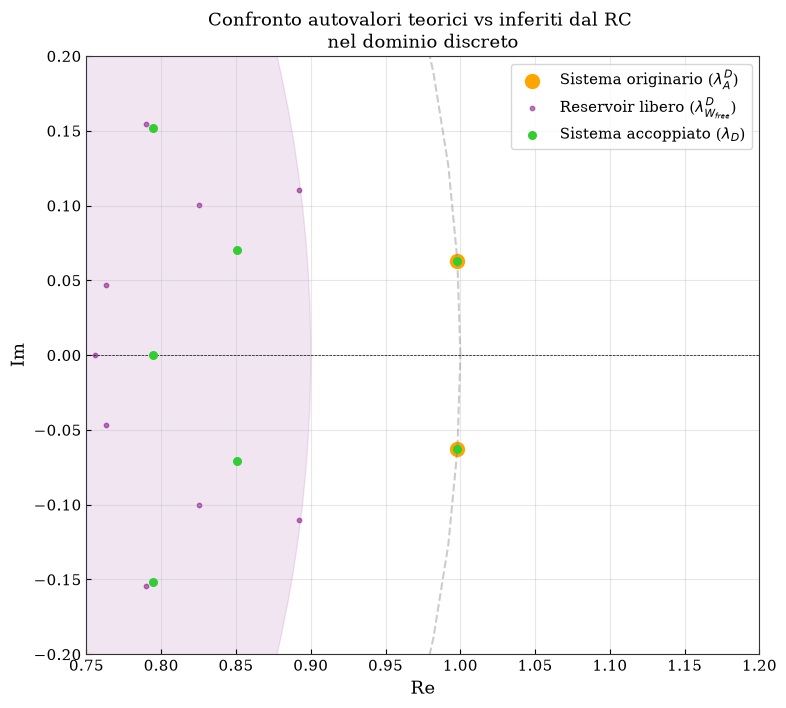

In [15]:
# =============================================================================
# 7. VISUALIZZAZIONE DELLO SPETTRO - dominio discreto
# =============================================================================

### GRAFICO 1: Spettri a confronto

plt.figure(figsize=(8, 8))

# Disegniamo la circonferenza entro la ESP e la circonferenza unitaria (il limite di stabilità)
plt.gca().add_patch(plt.Circle((0, 0), rho, alpha=0.1, color="purple"))
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='gray', alpha=0.4)

plt.scatter(np.real(lambda_A_D), np.imag(lambda_A_D), s=100, color="orange", zorder=1, label=r"Sistema originario ($\lambda_A^D$)") #($\lambda_A$)
plt.scatter(np.real(lambda_W_free_D), np.imag(lambda_W_free_D), s=10, color="purple", alpha=0.5, label=r"Reservoir libero ($\lambda_{W_{free}}^D$)") #(matrice $W-I$)
plt.scatter(np.real(lambda_D), np.imag(lambda_D), s=30, color="limegreen", zorder=3, label=r"Sistema accoppiato ($\lambda_D$)") #(matrice $W_{eff}$, autovalori $\lambda_C$)

#plt.scatter(np.real(lambda_C_Euler), np.imag(lambda_C_Euler), s=10, color="limegreen", zorder=3, label=r"Sistema accoppiato DISCRETO")

plt.gca().set_aspect('equal', 'box')

plt.xlim(0.75, 1.2) 
plt.ylim(-0.2, 0.2)
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.title("Confronto autovalori teorici vs inferiti dal RC \nnel dominio discreto")
plt.xlabel("Re")
plt.ylabel("Im")
plt.legend(loc="best", prop={'size': 11})
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#plt.savefig('spettro.png', dpi=300, bbox_inches='tight')

$-$ **I due punti arancioni** corrispondono agli autovalori discreti del sistema armonico campionato, $\lambda_{A\pm}^D= e^{\pm i \omega \Delta t}$.

$-$ **I punti viola** mostrano la distribuzione casuale iniziale dei neuroni isolati.

$-$ **I punti verdi** mostrano lo spostamento dei poli dopo l'addestramento. La prova del corretto funzionamento del Reservoir Computing sta nella comparsa di punti verdi che intersecano o si avvicinano drasticamente ai punti arancioni del sistema teorico.

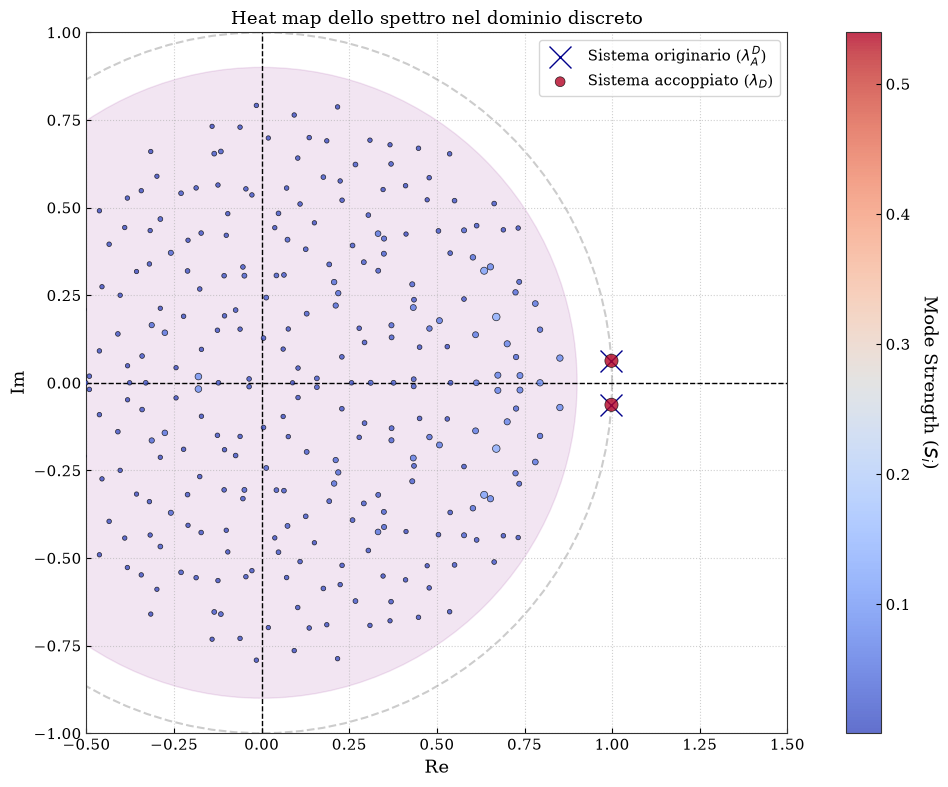

In [16]:
### GRAFICO 2: Heat map

plt.figure(figsize=(12, 8))
# Disegniamo la circonferenza entro la ESP e la circonferenza unitaria (il limite di stabilità)
plt.gca().add_patch(plt.Circle((0, 0), rho, alpha=0.1, color="purple"))
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='gray',  alpha=0.4)

# Plottiamo gli autovalori teorici del sistema originario (A)
#plt.scatter(np.real(lambda_A), np.imag(lambda_A), s=50, color="orange", zorder=3, label="Sistema originario (A)")
plt.scatter(np.real(lambda_A_D), np.imag(lambda_A_D), 
            marker='x', s=250, color='darkblue', linewidths=1, 
            zorder=2, label=r'Sistema originario ($\lambda_A^D$)')

# Plottiamo gli autovalori continui inferiti dal Reservoir.
# La MAGNITUDINE (s) e il COLORE (c) dipendono dalla Mode Strength (S).
scatter = plt.scatter(np.real(lambda_D), np.imag(lambda_D), 
                      c=S, cmap='coolwarm',
                      s=10 + 80 * (S / np.max(S)),  # Scala la grandezza dei punti
                      alpha=0.8, edgecolors='k', linewidth=0.5, zorder=3, 
                      label=r'Sistema accoppiato ($\lambda_D$)')

plt.gca().set_aspect('equal', 'box')


# Barra dei colori per la Mode Strength
cbar = plt.colorbar(scatter)
cbar.set_label('Mode Strength ($S_i$)', rotation=270, labelpad=20)

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(0, color='black', linewidth=1, linestyle='--')

# Limiti degli assi: zoom sull'asse immaginario
plt.xlim(-0.5, 1.5) 
plt.ylim(-1, 1)

plt.xlabel('Re')
plt.ylabel('Im')
plt.legend(loc="upper right", prop={'size': 11})
plt.title('Heat map dello spettro nel dominio discreto')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')

## Visualizzazione accorpata nel dominio discreto

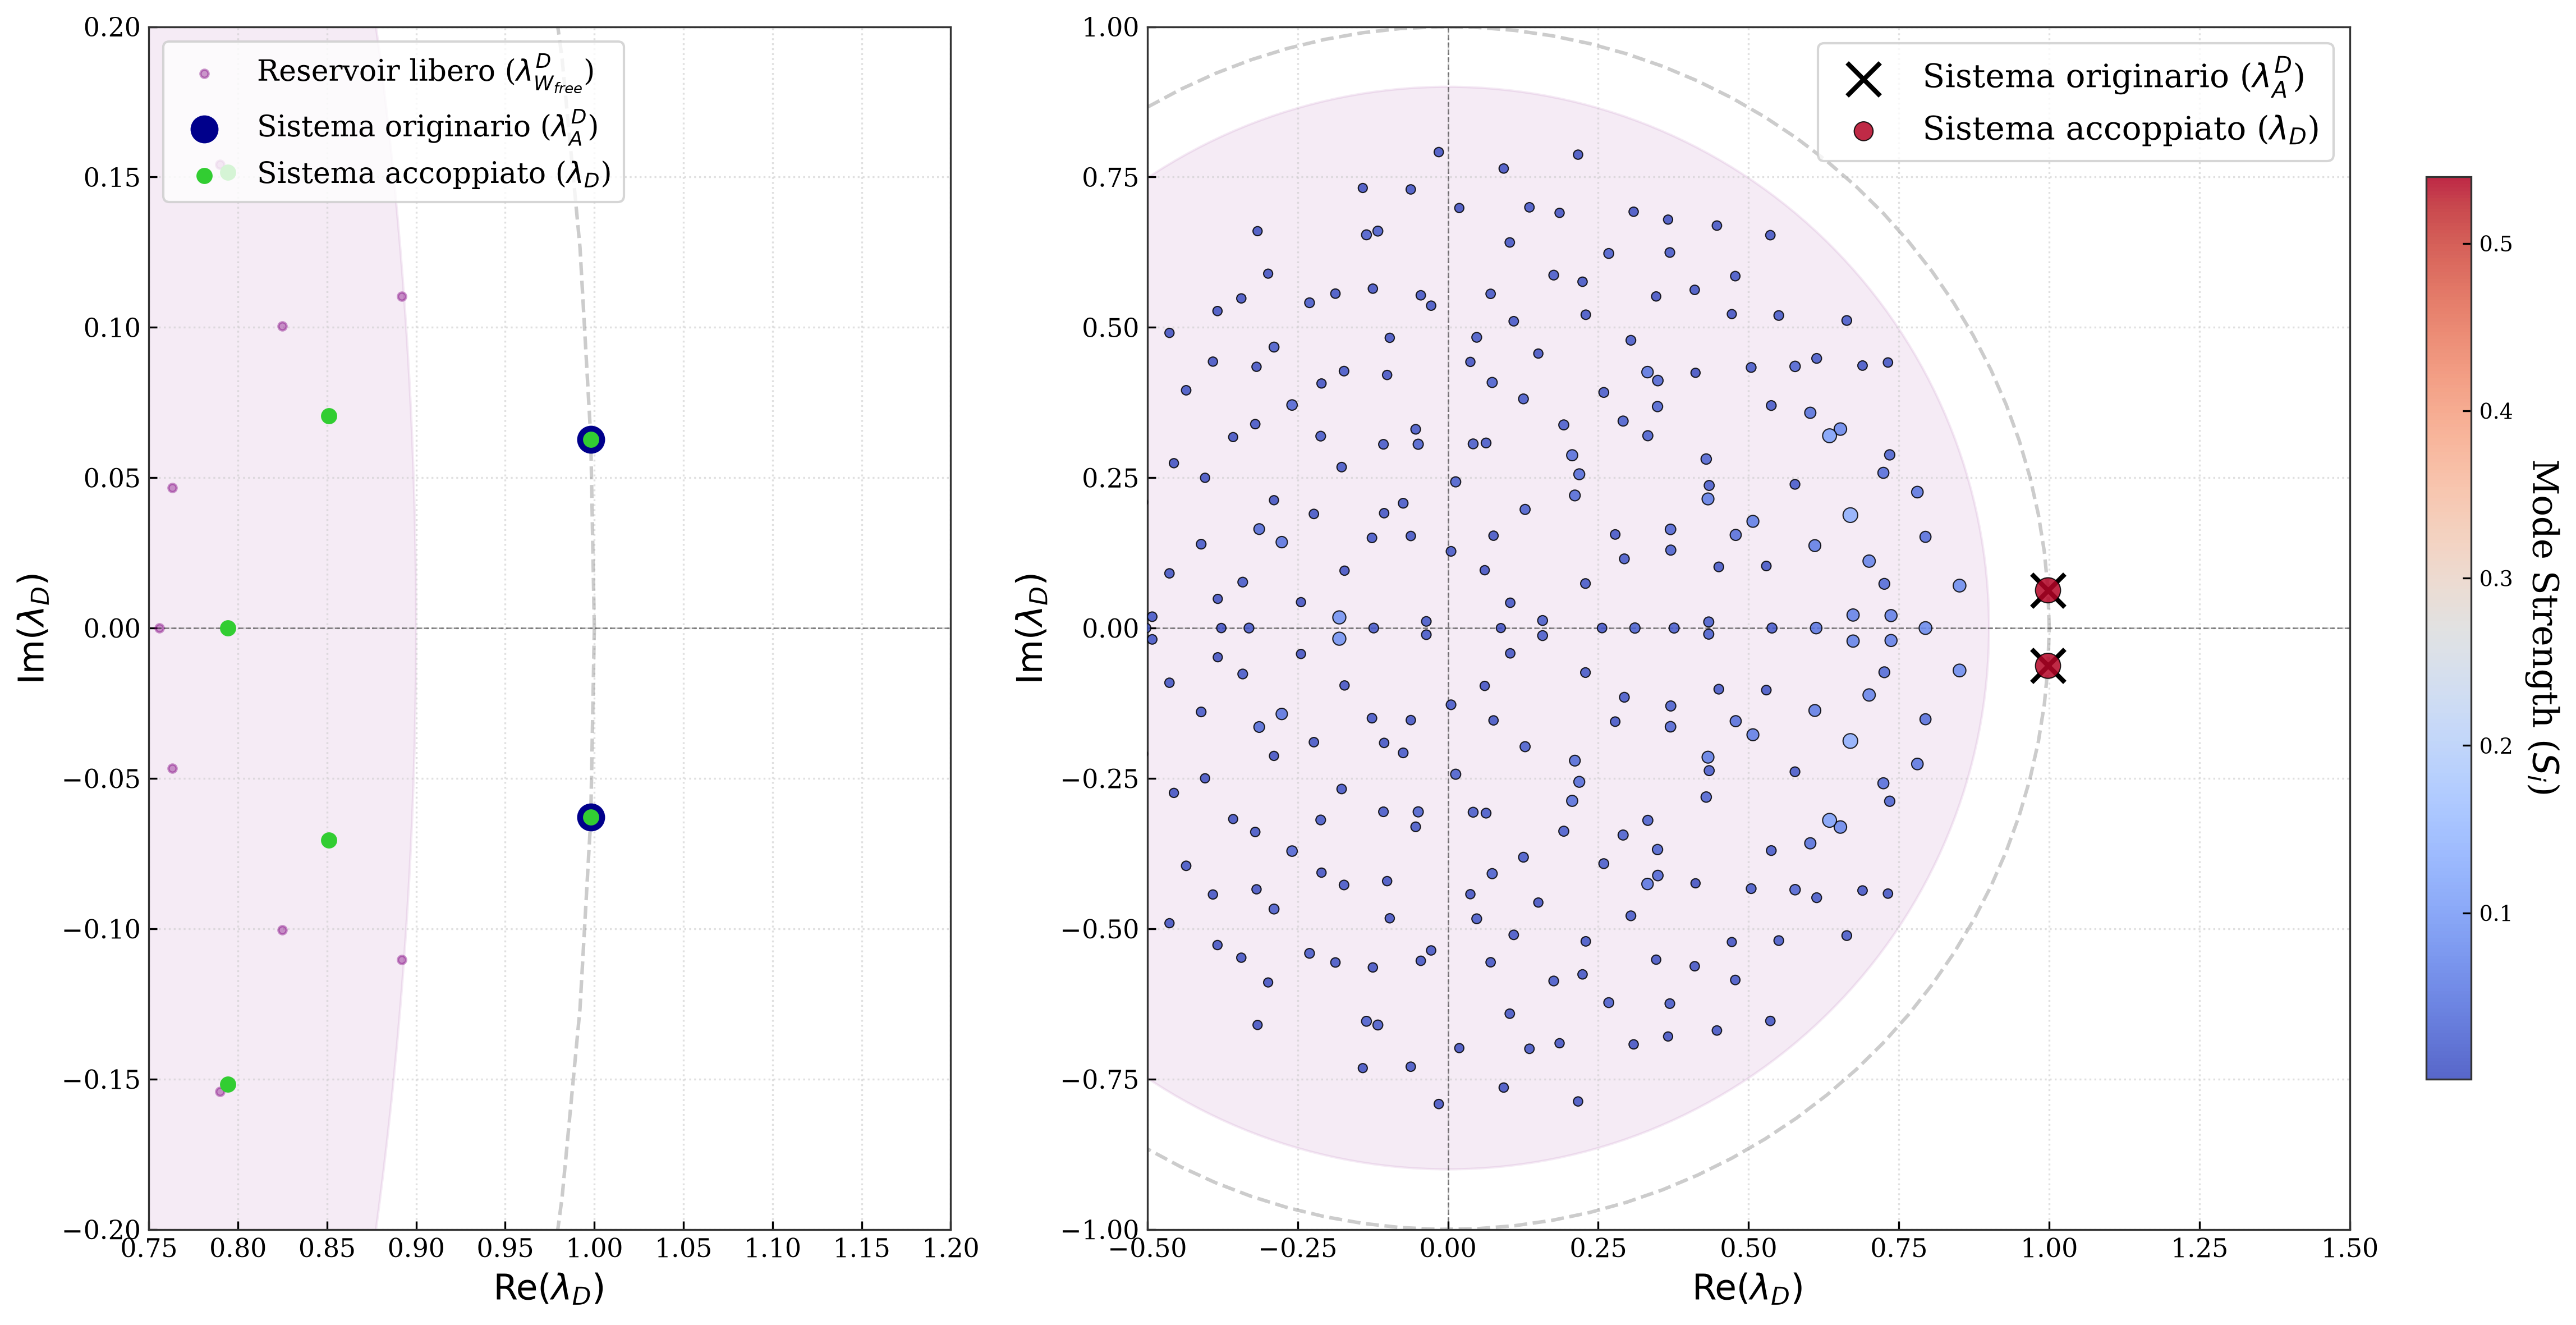

In [17]:
### VISUALIZZAZIONE ACCORPATA

# Creiamo un subplot unico a due pannelli affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), dpi=300, gridspec_kw={'width_ratios': [1, 1.9]})
theta = np.linspace(0, 2*np.pi, 100)

# =============================================================================
# PANNELLO A: CONFRONTO SPETTRI DISCRETI
# =============================================================================
# Disegniamo la circonferenza ESP e la circonferenza unitaria
ax1.add_patch(plt.Circle((0, 0), rho, alpha=0.08, color="purple"))
ax1.plot(np.cos(theta), np.sin(theta), linestyle='--', color='gray', alpha=0.4)

# Plot dei tre sistemi
ax1.scatter(np.real(lambda_W_free_D), np.imag(lambda_W_free_D), s=12, color="purple", alpha=0.4, zorder=2, label=r"Reservoir libero ($\lambda_{W_{free}}^D$)")
ax1.scatter(np.real(lambda_A_D), np.imag(lambda_A_D), s=120, color="darkblue", zorder=3, label=r"Sistema originario ($\lambda_A^D$)")
ax1.scatter(np.real(lambda_D), np.imag(lambda_D), s=35, color="limegreen", zorder=4, label=r"Sistema accoppiato ($\lambda_D$)")

#ax1.set_aspect('equal', 'box')
ax1.set_xlim(0.75, 1.2) 
ax1.set_ylim(-0.2, 0.2)
ax1.axhline(0, color='black', lw=0.6, ls='--', alpha=0.5)
ax1.axvline(0, color='black', lw=0.6, ls='--', alpha=0.5)

# Etichette piano complesso adimensionale
ax1.set_xlabel(r"$\text{Re}(\lambda_D)$", fontsize=15)
ax1.set_ylabel(r"$\text{Im}(\lambda_D)$", fontsize=15)
ax1.legend(loc="upper left", fontsize=12.5, frameon=True, facecolor='white')
ax1.grid(True, linestyle=':', alpha=0.6, color='#cccccc')


# =============================================================================
# PANNELLO B: HEAT MAP DELLE MODE STRENGTHS
# =============================================================================
ax2.add_patch(plt.Circle((0, 0), rho, alpha=0.08, color="purple"))
ax2.plot(np.cos(theta), np.sin(theta), linestyle='--', color='gray', alpha=0.4)


ax2.scatter(np.real(lambda_A_D), np.imag(lambda_A_D), marker='x', s=200, color='black', linewidths=2, zorder=3, label=r'Sistema originario ($\lambda_A^D$)')

# Spettro pesato con la Mode Strength
scatter = ax2.scatter(np.real(lambda_D), np.imag(lambda_D), 
                      c=S, cmap='coolwarm',
                      s=15 + 100 * (S / np.max(S)),  
                      alpha=0.85, edgecolors='k', linewidth=0.5, zorder=4, 
                      label=r'Sistema accoppiato ($\lambda_D$)')

ax2.set_aspect('equal', 'box')
ax2.set_xlim(-0.5, 1.5) 
ax2.set_ylim(-1.0, 1.0)
ax2.axhline(0, color='black', lw=0.6, ls='--', alpha=0.5)
ax2.axvline(0, color='black', lw=0.6, ls='--', alpha=0.5)

ax2.set_xlabel(r"$\text{Re}(\lambda_D)$", fontsize=15)
ax2.set_ylabel(r"$\text{Im}(\lambda_D)$", fontsize=15)
ax2.legend(loc="upper right", fontsize=14, frameon=True, facecolor='white')
ax2.grid(True, linestyle=':', alpha=0.6, color='#cccccc')

# Barra dei colori ancorata solo al secondo pannello (ax2)
cbar = fig.colorbar(scatter, ax=ax2, shrink=0.75, pad=0.05)
cbar.set_label('Mode Strength ($S_i$)', rotation=270, labelpad=20, fontsize=15)
cbar.ax.tick_params(labelsize=9)

# Layout e salvataggio
plt.tight_layout()
#plt.savefig('spettro_discreto_completo.pdf', dpi=300, bbox_inches='tight')
plt.show()


# Visualizzazione dello spettro nel dominio continuo (mappatura esatta)

Per confrontare le frequenze estratte dalla rete con la vera fisica del sistema dinamico originario, dobbiamo mappare lo spettro discreto indietro nel dominio del tempo continuo tramite l'inversa dell'operatore esponenziale (il logaritmo complesso).

In questo passaggio, cambiano le "regole" geometriche e fisiche dello spazio:
1. **Stabilità:** Il limite di stabilità non è più una circonferenza, ma coincide con l'**asse immaginario** ($\text{Re} = 0$).
2. **Dimensioni Fisiche:** Gli autovalori tornano a rappresentare tassi di decadimento (parte reale) e pulsazioni (parte immaginaria), misurati in radianti al secondo ($\text{rad/s}$).

L'applicazione del logaritmo genera un forte stiramento geometrico: i modi non rilevanti del reservoir (molto smorzati nel discreto) vengono mappati verso valori reali fortemente negativi (verso $-\infty$), creando una caratteristica "coda" dissipativa. Al contrario, i modi fisici dominanti (evidenziati dalla Mode Strength elevata) possono risultare prossimi all'asse immaginario e, nel caso ideale, agli autovalori teorici $\pm i \omega$.

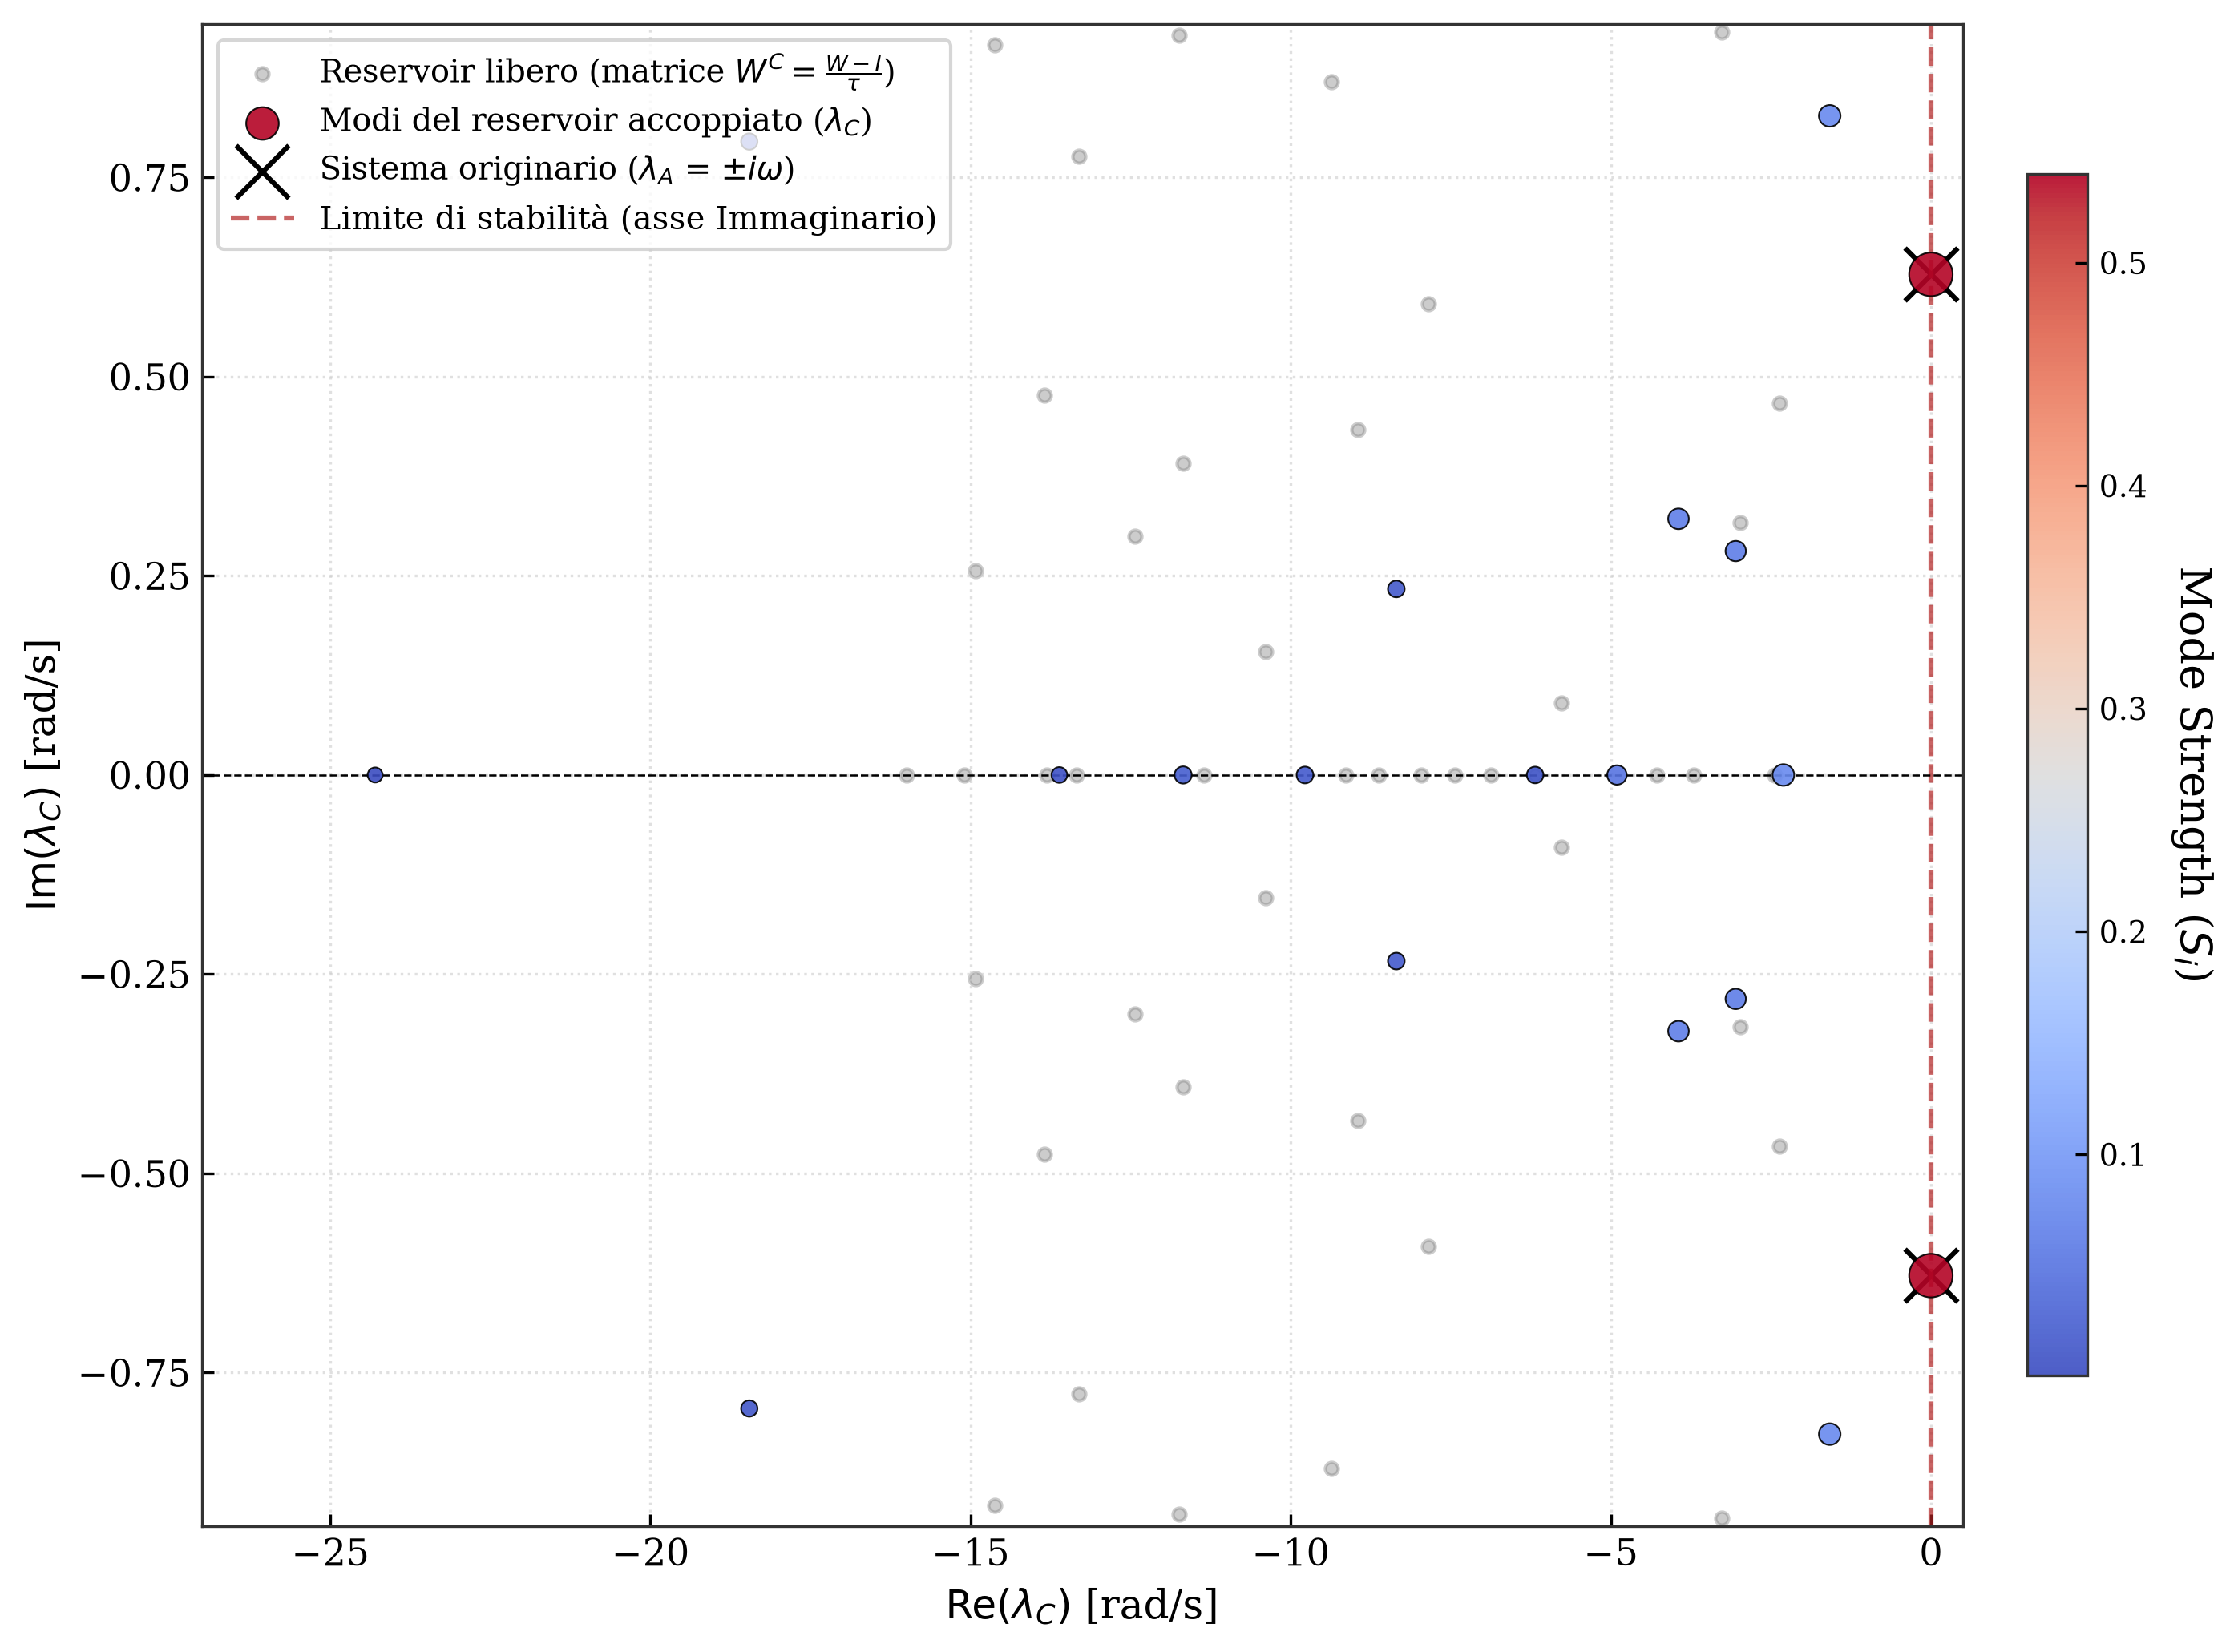

In [18]:
# =============================================================================
# 8. VISUALIZZAZIONE DELLO SPETTRO - dominio continuo
# =============================================================================

plt.figure(figsize=(10, 7), dpi=300)

# Nuvola del Reservoir libero (grigia, diffusa)
plt.scatter(np.real(lambda_W_free_C), np.imag(lambda_W_free_C), 
            s=15, color="gray", alpha=0.4, zorder=1, label=r"Reservoir libero (matrice $W^C = \frac{W-I}{\tau}$)")

# Nuvola del Reservoir Accoppiato (Heat map basata su Mode Strength)
# Il logaritmo "stira" i modi non rilevanti verso -infinito creando un effetto "cometa"
scatter = plt.scatter(np.real(lambda_C_exact), np.imag(lambda_C_exact), 
                      c=S, cmap='coolwarm', 
                      s=20 + 150 * (S / np.max(S)), # Dimensione scalata
                      alpha=0.9, edgecolors='k', linewidth=0.5, zorder=3, 
                      label=r"Modi del reservoir accoppiato ($\lambda_C$)")

# Target Teorico (Le X nere sull'asse immaginario)
plt.scatter(np.real(lambda_A), np.imag(lambda_A), 
            marker='x', s=250, color='black',
            zorder=2, label=r'Sistema originario ($\lambda_A$ = $\pm i\omega$)')

# L'asse immaginario (il limite di stabilità nel continuo)
plt.axvline(0, color='firebrick', lw=1.5, ls='--', alpha=0.7, label="Limite di stabilità (asse Immaginario)")
plt.axhline(0, color='black', lw=0.6, ls='--')

# LIMITI DEGLI ASSI:
# Poiché il logaritmo spinge i modi spuri verso Re -> -infinito, 
# applichiamo uno "zoom" sulla zona fisicamente rilevante per non comprimere il grafico.
lim_x = -3.0 / tau  # Regolare
plt.xlim(lim_x, 0.5)
plt.ylim(-omega * 1.5, omega * 1.5)

cbar = plt.colorbar(scatter, shrink=0.8, pad=0.03)
cbar.set_label('Mode Strength ($S_i$)', rotation=270, labelpad=20, fontsize=13)
cbar.ax.tick_params(labelsize=9)

#plt.title("Heat map dello spettro nel dominio continuo (mappatura esatta)")
plt.xlabel(r"$\text{Re}(\lambda_C)$ [rad/s]", fontsize=12)
plt.ylabel(r"$\text{Im}(\lambda_C)$ [rad/s]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
plt.legend(loc="upper left", fontsize=9.5, frameon=True, facecolor='white')
plt.tight_layout()
#plt.savefig('spettro_continuo_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Ablazione dell'input e analisi PCA (ricostruzione della dinamica da una singola osservabile)
Fino a questo momento, l'addestramento della rete è stato condotto fornendo in input l'intero stato del sistema dinamico, ovvero un vettore bidimensionale contenente sia la posizione che la velocità $\mathbf{u}(t) = [x(t), v(t)]^T$. Tuttavia, nei contesti sperimentali reali — come, ad esempio, la registrazione elettrofisiologica di un potenziale d'azione neuronale — l'accesso simultaneo a tutte le variabili di stato è raramente possibile; tipicamente, il sistema viene campionato attraverso una singola osservabile scalare nel tempo. 

Sfruttando le garanzie teoriche fornite dal Teorema di Embedding di Takens, ipotizziamo l'esistenza di un diffeomorfismo (un'equivalenza topologica) tra l'attrattore originale e lo spazio ricostruito a partire dall'osservazione di un'unica variabile ritardata nel tempo. 

L'esperimento di ablazione mira a verificare empiricamente se la *fading memory* del reservoir agisca efficacemente da surrogato per il *delay embedding*, consentendo il recupero della dimensionalità latente. Forniamo quindi al sistema esclusivamente la posizione $x_t$ (riducendo la dimensionalità a $D=1$) e analizziamo la capacità della rete di dedurre la corretta struttura geometrica del sistema originario.

## Fading Memory e formulazione in serie dello stato
Per comprendere come la rete costruisca autonomamente le coordinate di ritardo di Takens, consideriamo la dinamica dell'equazione di aggiornamento (introdotta nel Paragrafo 3) durante la fase di open-loop, in cui la rete è guidata unicamente dal segnale scalare in ingresso $x_t$. Raccogliendo lo stato al passo precedente, l'equazione assume la forma:
$$\mathbf{h}_t = ((1-\alpha)\mathbf{I} + \alpha \mathbf{W})\mathbf{h}_{t-1} + \alpha \mathbf{W}_{\text{in}} x_t$$
Notiamo che l'operatore che moltiplica $\mathbf{h}_{t-1}$ coincide esattamente con la matrice del propagatore discreto del reservoir isolato, che definiremo $\mathbf{W}_{\text{free}}^D = (1-\alpha)\mathbf{I} + \alpha \mathbf{W}$. Applicando questa relazione ricorsivamente all'indietro nel tempo (e assumendo l'esaurimento dei transienti per $t_0 \to -\infty$), lo stato corrente si espande in una serie infinita:
$$\mathbf{h}_t = \alpha \sum_{k=0}^{\infty} (\mathbf{W}_{\text{free}}^D)^k \mathbf{W}_{\text{in}} x_{t-k}$$
Questa espressione formale costituisce la base matematica dell'embedding implicito. Essa dimostra che lo stato interno $\mathbf{h}_t$ è, a tutti gli effetti, una combinazione lineare pesata della storia degli input $\{x_t, x_{t-1}, x_{t-2}, \dots\}$. La condizione del raggio spettrale $\rho(\mathbf{W}) < 1$ garantisce che gli autovalori di $\mathbf{W}_{\text{free}}^D$ risiedano all'interno del disco unitario, imponendo un decadimento temporale che dota il sistema di fading memory: gli input remoti contribuiscono in misura esponenzialmente decrescente. Il reservoir agisce così come una linea di ritardo temporale ad altissima dimensionalità.



## Analisi delle Componenti Principali (PCA) e collasso dimensionale
Sebbene lo stato della rete $\mathbf{h}_t$ evolva nello spazio a $N=300$ dimensioni del reservoir, l'informazione fisica del sistema risiede su una varietà a dimensionalità intrinseca nettamente inferiore. L'Analisi delle Componenti Principali (PCA) fornisce lo strumento algebrico per caratterizzare la dimensionalità lineare dominante della rappresentazione degli stati del reservoir, proiettando le dinamiche degli $N=300$ neuroni nello spazio ridotto delle loro componenti a varianza massimizzata. 

Data la matrice degli stati interni centrata rispetto alla propria media temporale, $\tilde{\mathbf{H}} \in \mathbb{R}^{T \times N}$, si definisce la matrice di covarianza campionaria:
$$\mathbf{C} = \frac{1}{T-1} \tilde{\mathbf{H}}^T \tilde{\mathbf{H}} \quad \in \mathbb{R}^{N \times N}$$
La PCA consiste nella risoluzione del problema spettrale per la matrice simmetrica $\mathbf{C}$:
$$\mathbf{C} \mathbf{v}_i = \lambda^{PCA}_i \mathbf{v}_i$$
dove gli autovettori $\mathbf{v}_i$ (le Componenti Principali) identificano le direzioni di massima varianza nello spazio degli stati, e i rispettivi autovalori $\lambda^{PCA}_i \ge 0$ quantificano la varianza catturata lungo tali assi. (Si noti che $\lambda^{PCA}_i$ quantifica una dispersione statistica, e non va confuso con gli autovalori dinamici $\lambda_C$ che governano l'evoluzione temporale). Ordinando gli autovalori in modo decrescente, la proporzione di varianza totale spiegata dalle prime $k$ componenti è data dalla traccia frazionaria:
$$R_k = \frac{\sum_{i=1}^k \lambda^{PCA}_i}{\sum_{i=1}^N \lambda^{PCA}_i}$$

Di nuovo, se il reservoir ha codificato correttamente la dinamica, ci aspettiamo due evidenze formali: in primo luogo, che la varianza del sistema si concentri quasi integralmente su sole due Componenti Principali (rivelando la natura bidimensionale dell'oscillatore nascosta nell'osservabile unidimensionale); in secondo luogo, che la proiezione della traiettoria sul piano definito dalle prime due PC presenta una struttura orbitale coerente con quella dell'oscillatore armonico, preservando l'estrazione spettrale dei due autovalori dominanti corrispondenti alle frequenze naturali.

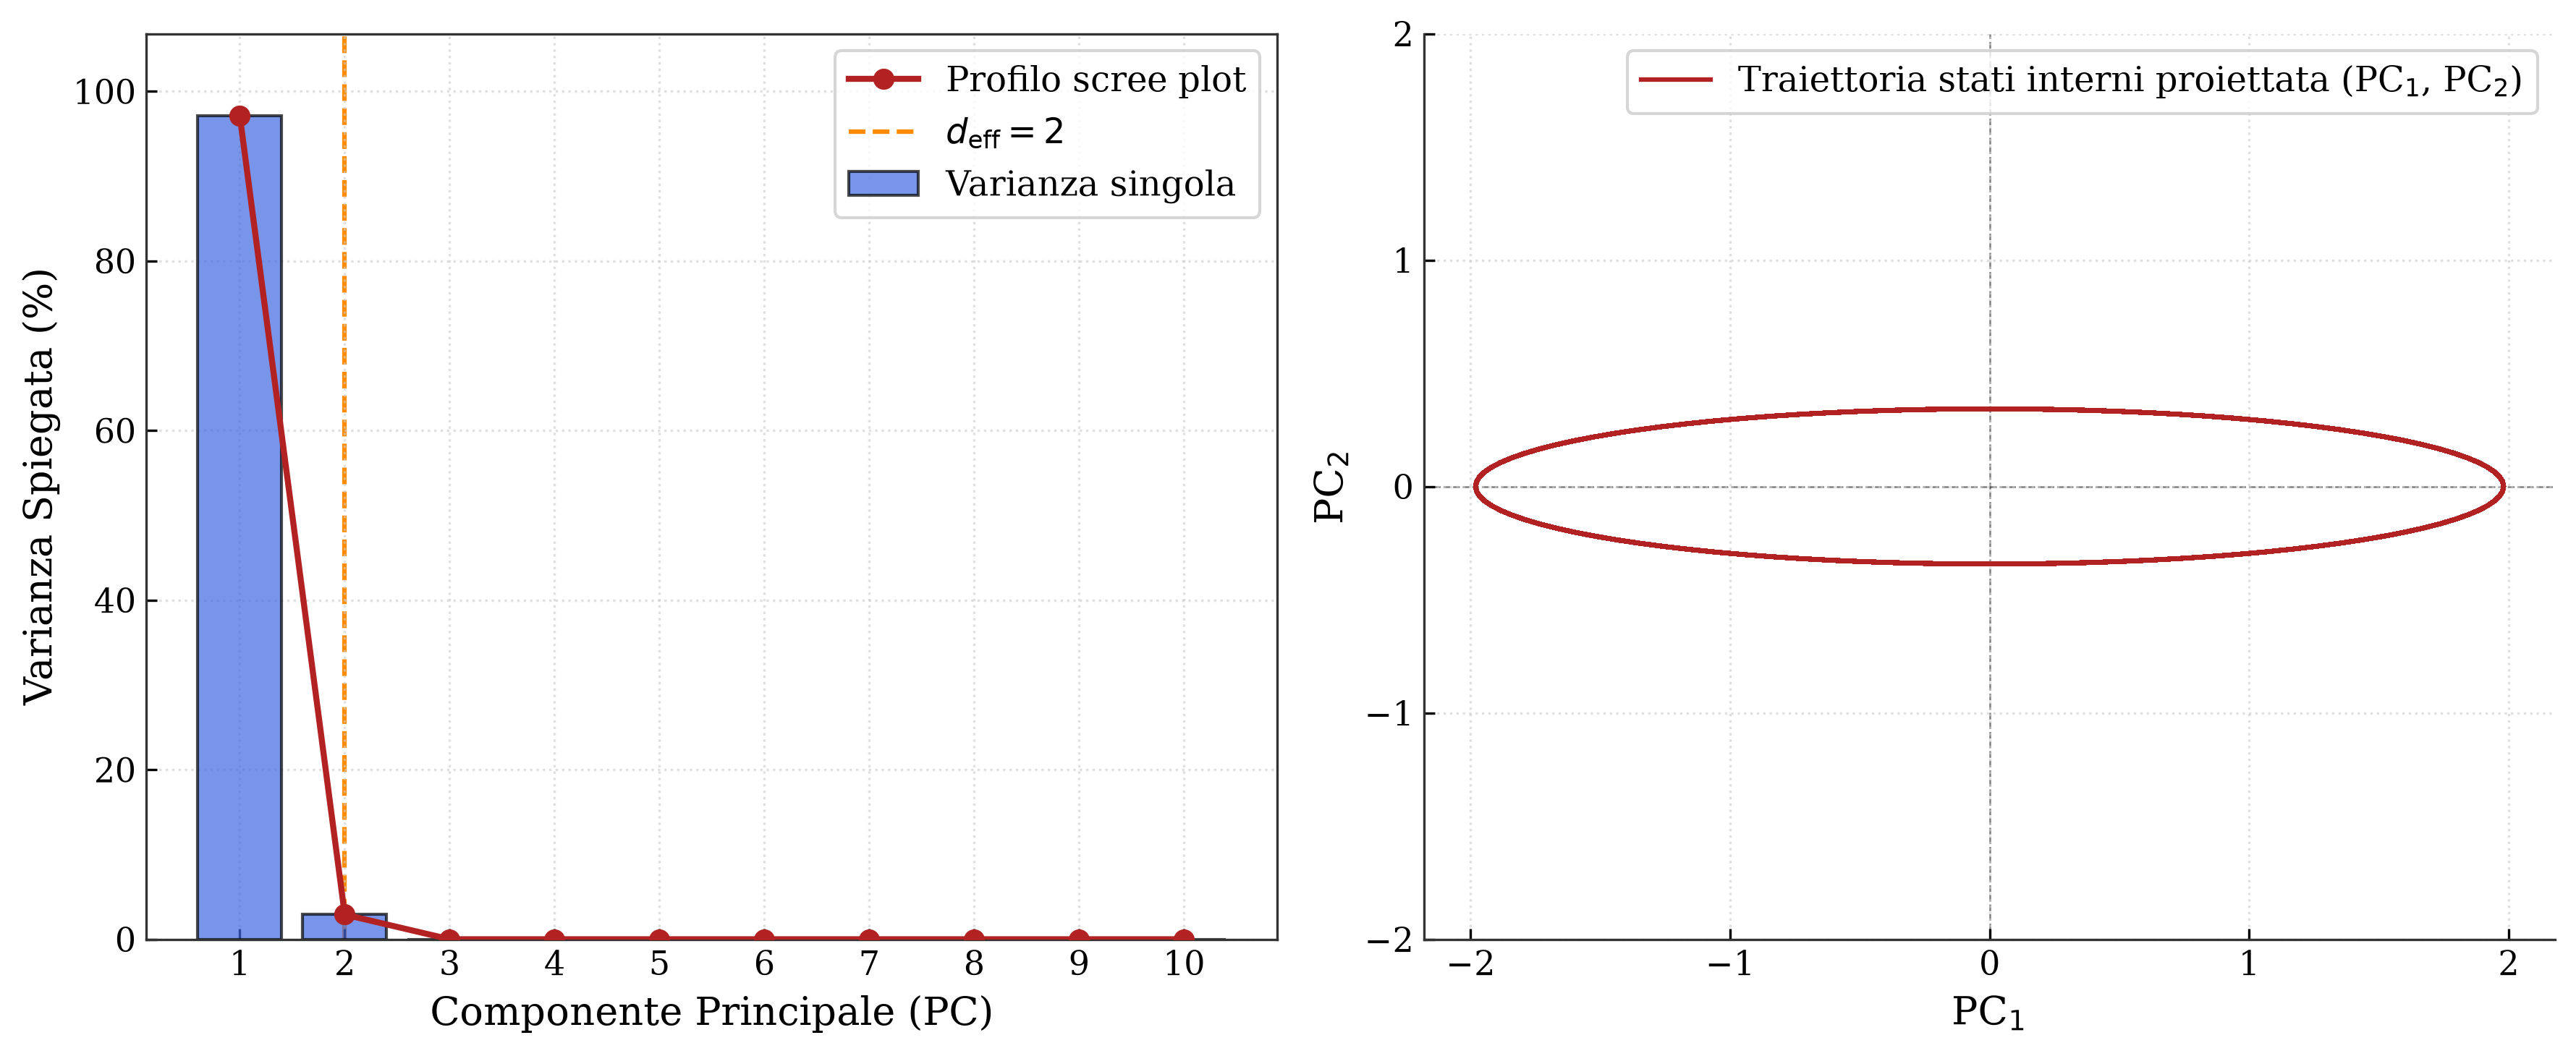

=== RISULTATI PCA ===
La PC1 spiega il 97.09% della varianza dello stato interno.
La PC2 spiega il 2.91% della varianza dello stato interno.
Le prime due PC insieme spiegano il 100.0000% dell'informazione totale.


In [19]:
from sklearn.decomposition import PCA

# =============================================================================
# 9. ABLAZIONE DELL'INPUT (D=1) E ANALISI PCA
# =============================================================================

# 1. Riduciamo il dataset a 1 dimensione (Solo la posizione x)
x_spin_1d  = x_spin[:, 0].reshape(-1, 1)
x_train_1d = x_train[:, 0].reshape(-1, 1)

# 2. Reinizializziamo solo la matrice di input Win per accettare D=1
D_1 = 1
np.random.seed(SEED + 1) #Seed fissato per riproducibilità
Win_1d = input_scaling * np.random.randn(N, D_1) / np.sqrt(N)

# 3. Evoluzione del sistema con una sola variabile in input
h_spin_1d = open_loop(x_spin_1d, np.zeros(N), W, Win_1d, b, alpha)
h_train_1d = open_loop(x_train_1d, h_spin_1d[-1], W, Win_1d, b, alpha)


# =============================================================================
# APPLICAZIONE DELLA PCA SUGLI STATI INTERNI
# =============================================================================
# Inizializziamo la PCA. 
# Visualizziamo le prime 10 componenti per caratterizzare
# la distribuzione della varianza tra le direzioni principali.
pca = PCA(n_components=10)

# Eseguiamo la PCA sulla matrice degli stati interni h_train_1d (shape: T x 300)
# pca.fit_transform centra i dati e restituisce le proiezioni
h_pca = pca.fit_transform(h_train_1d)

# Varianza spiegata (in percentuale)
explained_variance = pca.explained_variance_ratio_ * 100


# =============================================================================
# VISUALIZZAZIONE DEI RISULTATI DELLA PCA
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=300)


### GRAFICO 1: Scree Plot (Dimensionalità effettiva)
# Barre della varianza individuale
ax1.bar(range(1, 11), explained_variance, color='royalblue', edgecolor='black', alpha=0.7, zorder=2, label='Varianza singola')

# Linea di trend (tipica dello Scree Plot per vedere il gomito)
ax1.plot(range(1, 11), explained_variance, marker='o', color='firebrick', linewidth=2, zorder=3, label='Profilo scree plot')

# Evidenziamo visivamente il "gomito" (PC2 è l'ultima significativa, il crollo è su PC3)
ax1.axvline(x=2, color='darkorange', linestyle='--', linewidth=1.5, zorder=1, label=r'$d_{\text{eff}}=2$')

#ax1.set_title("Analisi della dimensionalità degli Stati Interni (PCA)", fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel("Componente Principale (PC)", fontsize=13)
ax1.set_ylabel("Varianza Spiegata (%)", fontsize=13)

ax1.set_xticks(range(1, 11))
ax1.set_ylim(0, max(explained_variance) * 1.1)
ax1.grid(True, linestyle=':', alpha=0.6, color='#cccccc', zorder=1)
ax1.legend(loc='upper right', fontsize=11.5, frameon=True, facecolor='white')


### GRAFICO 2: Proiezione 2D dello stato del reservoir
ax2.plot(h_pca[:, 0], h_pca[:, 1], color='firebrick', linewidth=1.5, label='Traiettoria stati interni proiettata (PC$_1$, PC$_2$)')

#ax2.set_aspect('equal', 'datalim')
#ax2.set_title("Traiettoria dell'attrattore ricostruito dalla rete\nProiezione sul piano delle componenti PC1-PC2", fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel("PC$_1$", fontsize=13)
ax2.set_ylabel("PC$_2$", fontsize=13)

ax2.set_xticks([-2, -1, 0, 1, 2])
ax2.set_yticks([-2, -1, 0, 1, 2])

ax2.axhline(0, color='black', lw=0.6, ls='--', alpha=0.5, zorder=1)
ax2.axvline(0, color='black', lw=0.6, ls='--', alpha=0.5, zorder=1)
ax2.grid(True, linestyle=':', alpha=0.6, color='#cccccc', zorder=1)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(loc='upper right', fontsize=11.5, frameon=True, facecolor='white')


plt.tight_layout()
#plt.savefig('pca_OA_input1D.pdf', dpi=300, bbox_inches='tight')

plt.show()

print("=== RISULTATI PCA ===")
print(f"La PC1 spiega il {explained_variance[0]:.2f}% della varianza dello stato interno.")
print(f"La PC2 spiega il {explained_variance[1]:.2f}% della varianza dello stato interno.")
print(f"Le prime due PC insieme spiegano il {np.sum(explained_variance[:2]):.4f}% dell'informazione totale.")
print("=====================")

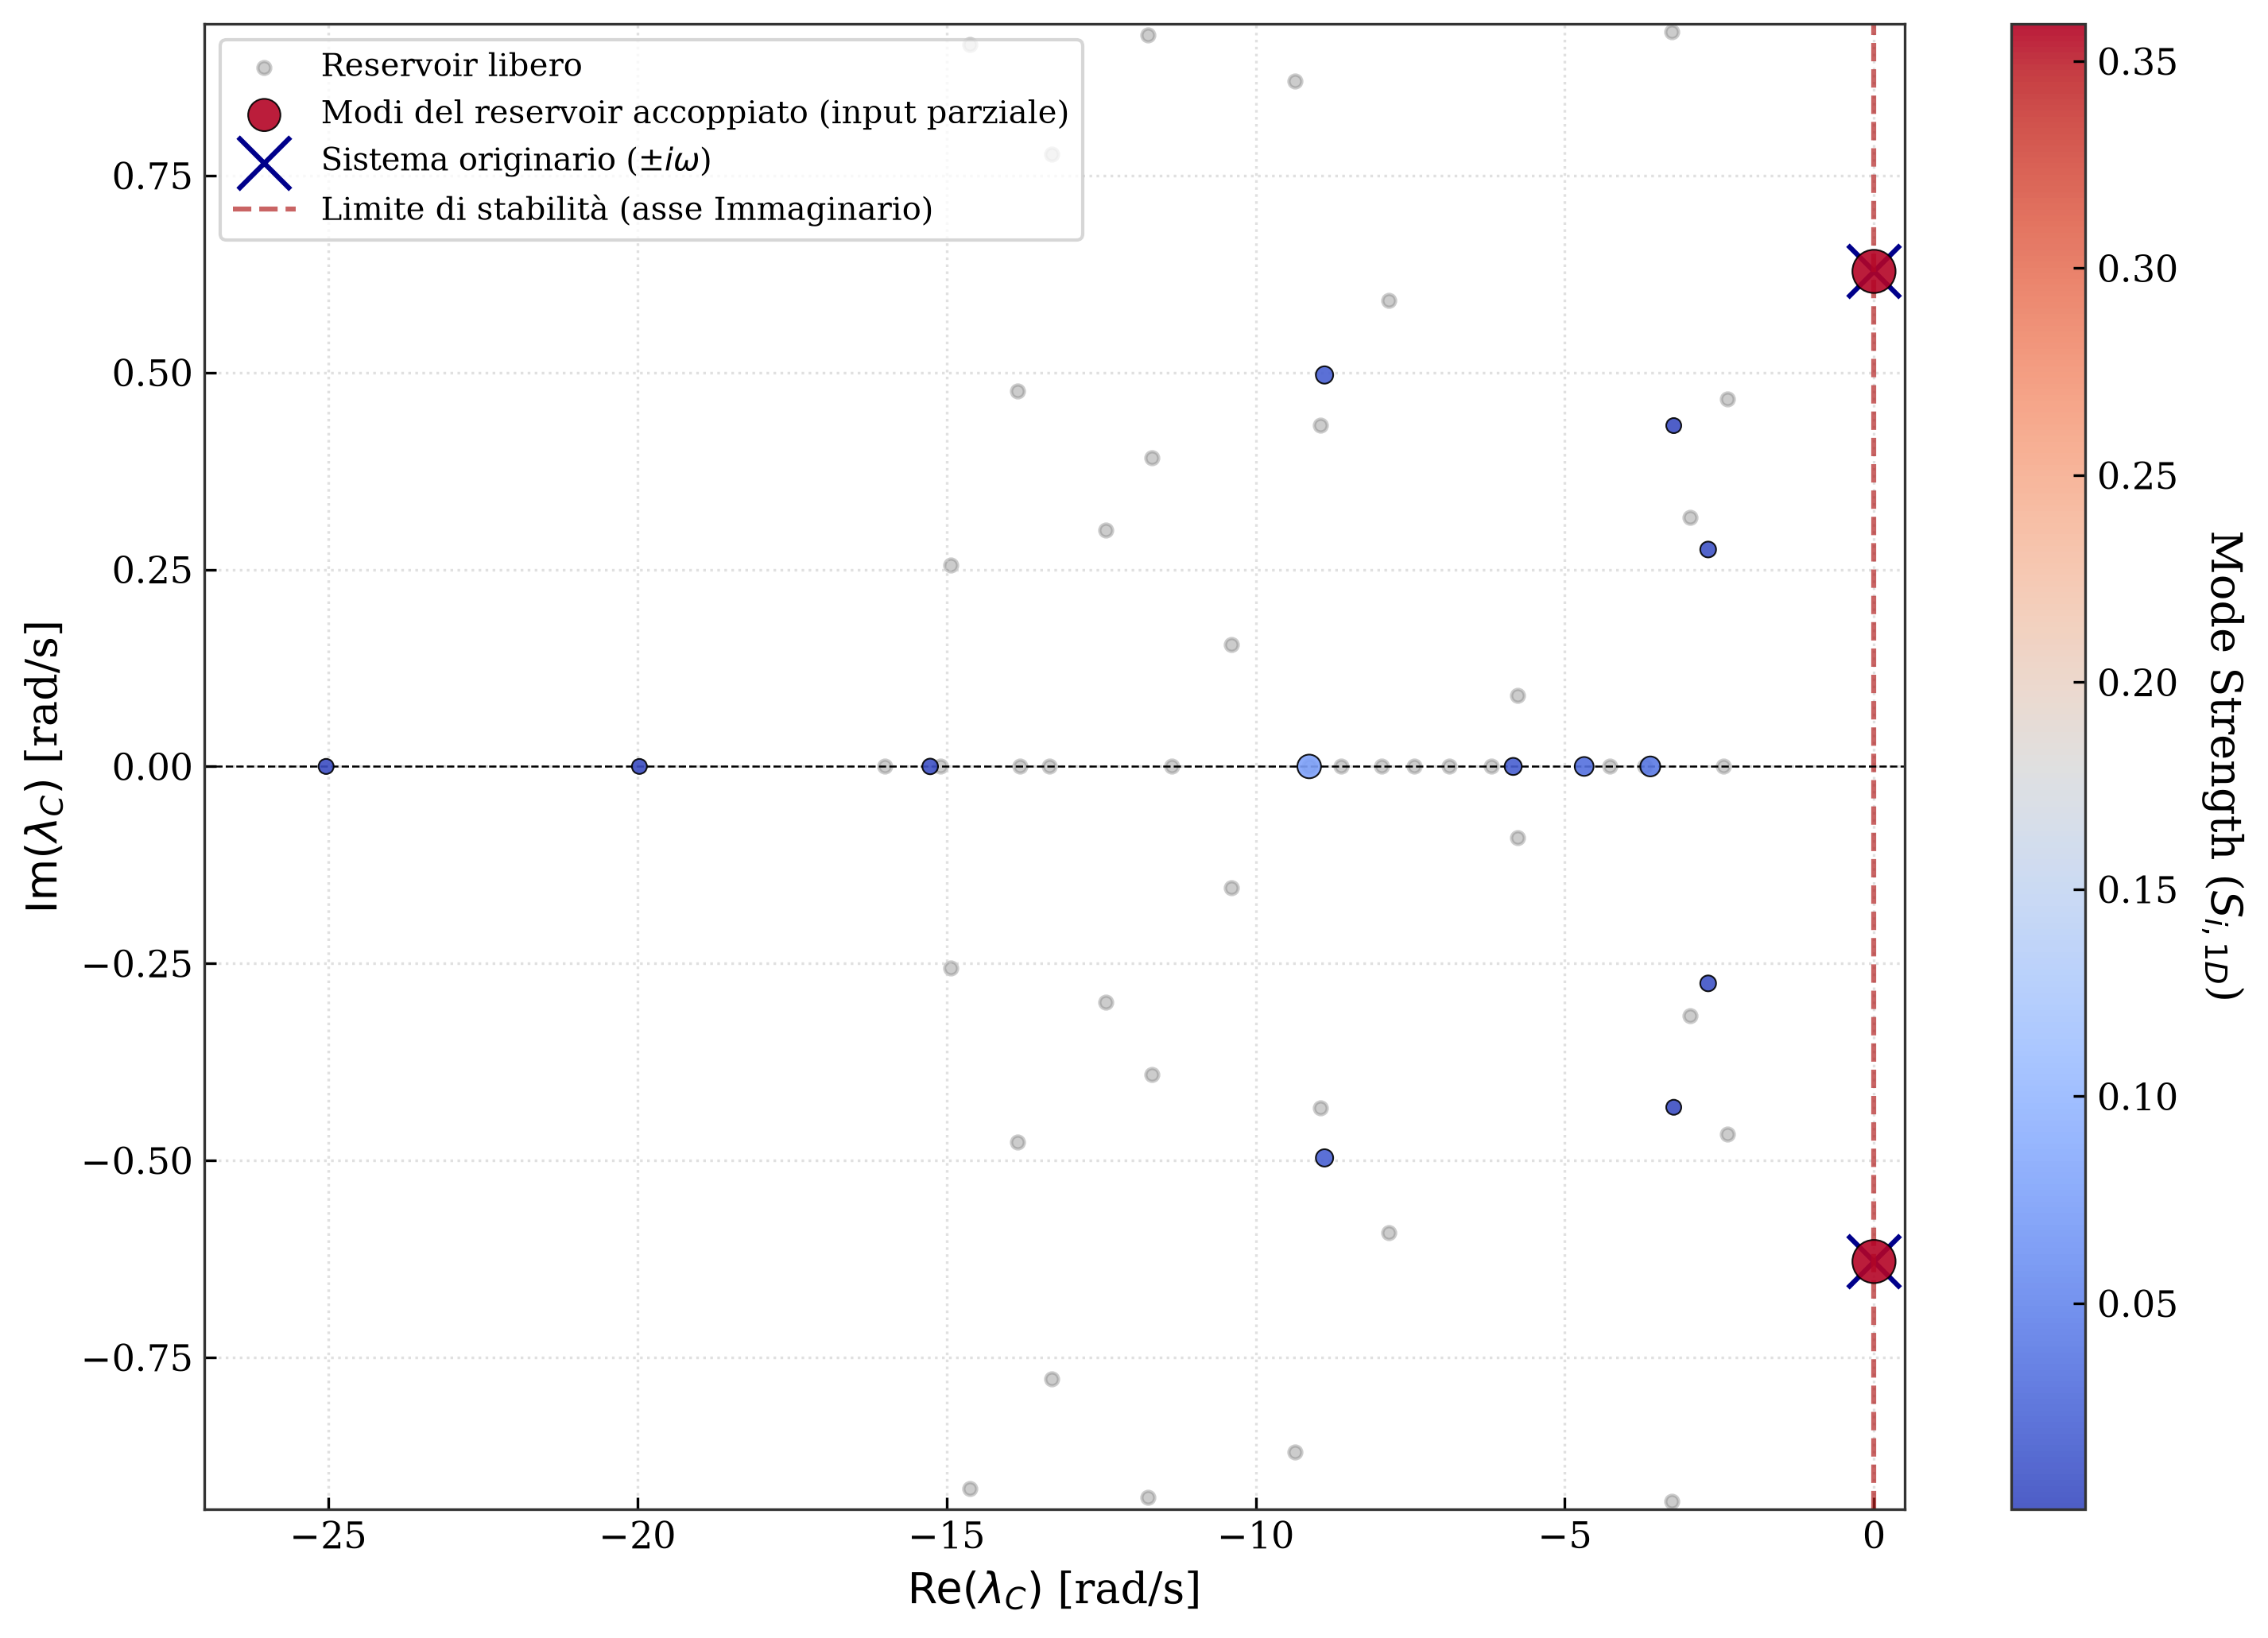

=== INFERENZA DA UNA SINGOLA OSSERVABILE ===
Autovalori inferiti dominanti:
1) -0.000000+0.628319j rad/s
2) -0.000000-0.628319j rad/s
Target teorico: ±0.628319j


In [20]:
# =============================================================================
# 10. INFERENZA SPETTRALE CON TIME EMBEDDING (input 1D)
# =============================================================================

# 1. Calcolo di Wout tramite pseudo-inversa regolarizzata per input 1D
H_train_shifted_1d = h_train_1d[:-1]
Y_target_shifted_1d = x_train_1d[1:]

Wout_1d = ridge_regression(H_train_shifted_1d, Y_target_shifted_1d, 1e-8)
Wout_1d = Wout_1d.reshape(1, N)

# 2. Propagatore discreto e mappatura continua
W_tot_1d = W + Win_1d @ Wout_1d
W_eff_D_1d = I + alpha * (W_tot_1d - I)
lambda_D_1d, V_1d = la.eig(W_eff_D_1d)
lambda_C_exact_1d = np.log(lambda_D_1d) / dt

# 3. Calcolo Mode Strengths (sulla singola variabile)
h0_1d = h_train_1d[-1]
c_1d = la.solve(V_1d, h0_1d)
mode_strengths_matrix_1d = Wout_1d @ V_1d @ np.diag(c_1d)
S_1d = np.linalg.norm(mode_strengths_matrix_1d, axis=0)

# =============================================================================
# VISUALIZZAZIONE DELLO SPETTRO (Heat Map continua in 1D)
# =============================================================================
plt.figure(figsize=(10, 7), dpi=300)


# Nuvola del reservoir libero
plt.scatter(np.real(lambda_W_free_C), np.imag(lambda_W_free_C), 
            s=15, color="gray", alpha=0.4, zorder=1, label=r"Reservoir libero")

# Modi del Reservoir accoppiato (heat map)
scatter = plt.scatter(np.real(lambda_C_exact_1d), np.imag(lambda_C_exact_1d), 
                      c=S_1d, cmap='coolwarm', 
                      s=20 + 150 * (S_1d / np.max(S_1d)), 
                      alpha=0.9, edgecolors='k', linewidth=0.5, zorder=3, 
                      label=r"Modi del reservoir accoppiato (input parziale)")

# Target Teorico
plt.scatter(np.real(lambda_A), np.imag(lambda_A), 
            marker='x', s=250, color='darkblue',
            zorder=2, label=r'Sistema originario ($\pm i\omega$)')

plt.axvline(0, color='firebrick', lw=1.5, ls='--', alpha=0.7, label="Limite di stabilità (asse Immaginario)")
plt.axhline(0, color='black', lw=0.6, ls='--')

lim_x = -3.0 / tau 
plt.xlim(lim_x, 0.5)
plt.ylim(-omega * 1.5, omega * 1.5)

cbar = plt.colorbar(scatter)
cbar.set_label('Mode Strength ($S_{i,1D}$)', rotation=270, labelpad=20, fontsize=13)

#plt.title("Confronto autovalori teorici vs inferiti dal RC con solo input 1D\nHeat map dello spettro nel dominio continuo")
plt.xlabel(r"$\text{Re}(\lambda_C)$ [rad/s]", fontsize=13)
plt.ylabel(r"$\text{Im}(\lambda_C)$ [rad/s]", fontsize=13)
plt.grid(True, linestyle=':', alpha=0.6, color='#cccccc')
plt.legend(loc="upper left", fontsize=9.5, frameon=True, facecolor='white')

plt.tight_layout()
#plt.savefig('spettro_continuo_input1D.pdf', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# STAMPA A SCHERMO: DIMENSIONALITÀ E FREQUENZE
# =============================================================================
indici_dominanti_1d = np.argsort(S_1d)[-2:]
lambda_C_dominanti_1d = lambda_C_exact_1d[indici_dominanti_1d]

print("=== INFERENZA DA UNA SINGOLA OSSERVABILE ===")
print("Autovalori inferiti dominanti:")
print(f"1) {lambda_C_dominanti_1d[0]:.6f} rad/s")
print(f"2) {lambda_C_dominanti_1d[1]:.6f} rad/s")
print(f"Target teorico: ±{omega:.6f}j")
print("===================================================")

L'analisi dello spettro continuo estratto a partire dalla sola variabile di posizione $x(t)$ conferma empiricamente che, nel caso dell'oscillatore armonico considerato, la rete Echo State è in grado di recuperare empiricamente i due modi dinamici dominanti associati alle frequenze $\pm \omega$. Il risultato, compatibile con l'idea generale del Teorema di Embedding di Takens di ricostruzione dello stato da osservazioni temporali,  mostra quindi che la memoria ricorrente del reservoir contiene informazione sufficiente a rappresentare la dinamica bidimensionale a partire da una singola osservabile scalare.

Nonostante la drastica riduzione della dimensionalità in input ($D=1$), il filtraggio tramite le *Mode Strengths* isola nuovamente due, e soltanto due, autovalori dominanti nello spettro del reservoir accoppiato. Tali autovalori si posizionano sull'asse immaginario in strettissima prossimità dei poli teorici del sistema originario ($\pm i\omega$). 

Questo risultato dimostra che la rete neurale non si limita a un semplice *curve fitting* unidimensionale, ma sfrutta la propria memoria interna (i pesi ricorrenti e il parametro di *leaking*) per ricostruire in uno spazio latente la componente di stato non osservata, implementando l'intero generatore dinamico del sistema fisico.


#### Commenti sul caso dell'Oscillatore Armonico
Nel caso specifico dell'oscillatore armonico, il collasso della dinamica su due sole Componenti Principali possiede una duplice interpretazione geometrico-fisica, che giustifica l'estrema precisione della rete nel ricostruire l'osservabile mancante (la velocità). Da un punto di vista dell'analisi differenziale nel dominio discreto, la velocità si approssima tramite la differenza finita all'indietro $v_t \approx \frac{x_t - x_{t-1}}{\Delta t}$. Essendo questa operazione una semplice combinazione lineare tra due passi temporali successivi, l'infrastruttura del reservoir (che, come dimostrato dall'espansione in serie, calcola nativamente somme pesate di input ritardati) è intrinsecamente predisposta a estrarre tale derivata. Dal punto di vista trigonometrico legato al target specifico, se l'osservabile fornita è $x_t = \sin(\omega t)$, la fading memory del sistema processerà input ritardati del tipo $\sin(\omega(t - \tau))$. Per le formule di addizione, un seno ritardato genera sempre una componente ortogonale:
$$\sin(\omega(t - \tau)) = \cos(\omega \tau)\sin(\omega t) - \sin(\omega \tau)\cos(\omega t)$$
Essendo la velocità analitica proporzionale al coseno ($\dot{x} \propto \cos(\omega t)$), la rete ha a disposizione, all'interno del proprio stato latente, le componenti funzionali per riprodurre lo spazio delle fasi. Proiettando gli stati $\mathbf{h}_t$ sul piano definito dagli autovettori dominanti $\mathbf{v}_1$ e $\mathbf{v}_2$, si osserva infatti l'emergenza di un'orbita ellittica conservativa, coerente con quella originale $(\mathbf{x}, \mathbf{v})$. La linearità della relazione che lega posizione e velocità nell'oscillatore armonico rende l'inferenza della derivata particolarmente agevole per il readout lineare (Ridge Regression), garantendo che la successiva analisi delle Mode Strengths isoli i due poli corretti sull'asse immaginario ($\pm i\omega$) pur partendo da una singola variabile misurata.